# 00. Data Structure and Exploratory Analysis

This notebook is the foundation for every later study in the project. It documents what the panel looks like before any modeling, runs the full diagnostic chain that constrains model choice, and adds three pieces of analysis that were missing from the midway report:

1. **Multi-horizon coupling** — the four horizons at the same `(code, sub_code, sub_category, ts_index)` are not independent series.
2. **Cumulation hypothesis** — the target at horizon `k` is approximately the rolling sum of the H1 process over `k` steps.
3. **Per-horizon weight concentration** — the maximum weight in the panel lives at H3, not H1, which means H3 disproportionately drives the weighted skill score.

The diagnostic sections (stationarity, ACF/PACF, STL, etc.) match the midway exploratory work and produce the figures used by the report. The new sections that come after are the originality contributions.


## 0. Setup

Imports, paths, and a single seed. The full panel with all 86 features is ~3.5 GB in pandas, so feature-level work runs on a stratified sample.


In [1]:
import sys
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import STL

from cf import io, viz, splits

viz.apply_report_style()

SEED = 0
np.random.seed(SEED)

KEY_COLS = ['code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'y_target', 'weight']
SERIES_KEYS = ['code', 'sub_code', 'sub_category', 'horizon']
FIG_DIR = io.FIGURES_DIR

print(f'Project root : {io.PROJECT_ROOT}')
print(f'Train cutoff : {splits.TRAIN_END}')
print(f'Figures dir  : {FIG_DIR}')

Project root : /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/claude_forecasting
Train cutoff : 2880
Figures dir  : /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/claude_forecasting/report/figures


In [2]:
train_keys = io.load_train_pandas(columns=KEY_COLS)
test_keys = io.load_test_pandas(columns=[c for c in KEY_COLS if c not in ('y_target', 'weight')])

print(f'train rows: {len(train_keys):,}')
print(f'test  rows: {len(test_keys):,}')

train rows: 5,337,414
test  rows: 1,447,107


## 1. Schema and panel structure

A row is identified by `(code, sub_code, sub_category, horizon, ts_index)`. The full panel has 23 codes, 180 sub-codes, 5 sub-categories, 4 horizons, and runs over `ts_index` 1 to 3601 in train, 3602 to 4376 in test.


In [3]:
overview = {
    'train_rows': len(train_keys),
    'test_rows': len(test_keys),
    'codes': train_keys['code'].nunique(),
    'sub_codes': train_keys['sub_code'].nunique(),
    'sub_categories': train_keys['sub_category'].nunique(),
    'horizons': sorted(train_keys['horizon'].unique().tolist()),
    'ts_index_train_range': (int(train_keys['ts_index'].min()), int(train_keys['ts_index'].max())),
    'ts_index_test_range': (int(test_keys['ts_index'].min()), int(test_keys['ts_index'].max())),
    'distinct_series': train_keys.groupby(SERIES_KEYS).ngroups,
}
pd.Series(overview).to_frame('value')

,value
train_rows,5337414
test_rows,1447107
codes,23
sub_codes,180
sub_categories,5
horizons,"[1, 3, 10, 25]"
ts_index_train_range,"(1, 3601)"
ts_index_test_range,"(3602, 4376)"
distinct_series,36923


**Reading.** Train ends at `ts_index = 3601`, test begins at `3602`, so test is a strict temporal suffix. Validation must respect chronology — random cross-validation would leak future information. The "distinct series" count uses `(code, sub_code, sub_category, horizon)` as the natural identifier.


## 2. Train vs test comparability

If train and test live on different schemas or different supports, naive modeling breaks.


In [4]:
import pyarrow.parquet as pq
train_schema = pq.read_schema(io.RAW_DIR / 'train.parquet')
test_schema = pq.read_schema(io.RAW_DIR / 'test.parquet')
train_cols = set(train_schema.names)
test_cols = set(test_schema.names)
print('Columns in train only:', sorted(train_cols - test_cols))
print('Columns in test only :', sorted(test_cols - train_cols))

cat_alignment = pd.DataFrame({
    'train_unique': [train_keys[c].nunique() for c in ['code', 'sub_code', 'sub_category', 'horizon']],
    'test_unique':  [test_keys[c].nunique() for c in ['code', 'sub_code', 'sub_category', 'horizon']],
}, index=['code', 'sub_code', 'sub_category', 'horizon'])
cat_alignment['test_subset_of_train'] = [
    set(test_keys[c].unique()).issubset(set(train_keys[c].unique()))
    for c in cat_alignment.index
]
cat_alignment

Columns in train only: ['weight', 'y_target']
Columns in test only : []


,train_unique,test_unique,test_subset_of_train
code,23,23,True
sub_code,180,47,False
sub_category,5,5,True
horizon,4,4,True


**Reading.** Train-only columns are exactly `y_target` and `weight` — labels and metric weights — which is correct. Every category level seen in test exists in train, so there is no cold-start schema problem. The `sub_code` cardinality drops from 180 in train to 47 in test, which is a coverage shift rather than a schema mismatch.


## 3. Missing values

Imputation strategy follows from how much is missing and where.


In [5]:
sample_for_missing = pd.read_parquet(io.RAW_DIR / 'train.parquet').sample(500_000, random_state=SEED)
missing = sample_for_missing.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(f'Columns with any missing values: {len(missing)}')
print(missing.head(10).round(4).to_string())

Columns with any missing values: 48
feature_at    0.1243
feature_by    0.1099
feature_ay    0.0860
feature_cd    0.0756
feature_ce    0.0516
feature_cf    0.0442
feature_al    0.0421
feature_aw    0.0386
feature_bz    0.0286
feature_bi    0.0280


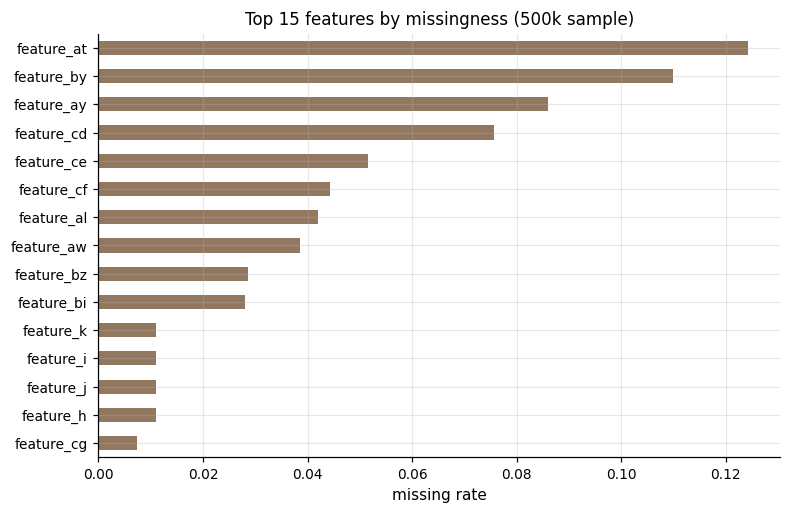

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
missing.head(15).sort_values().plot.barh(ax=ax, color='#937860')
ax.set_xlabel('missing rate')
ax.set_title('Top 15 features by missingness (500k sample)')
viz.save_figure(fig, '00_missingness_top15', FIG_DIR)
del sample_for_missing

**Reading.** No feature exceeds ~12.5% missing. This is low enough that simple median imputation inside a fold is sufficient. There is no need to drop columns or use complex imputers.


## 4. Target distribution

The target drives the metric, so we need its scale, centering, and tail behavior before choosing a loss or a baseline.


In [7]:
train_keys['y_target'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame().round(4)

,y_target
count,5.337414e+06
mean,-6.659000e-01
std,3.252760e+01
min,-2.201882e+03
1%,-8.279720e+01
5%,-7.606800e+00
25%,-1.291000e-01
50%,-6.000000e-04
75%,5.110000e-02
95%,4.504700e+00


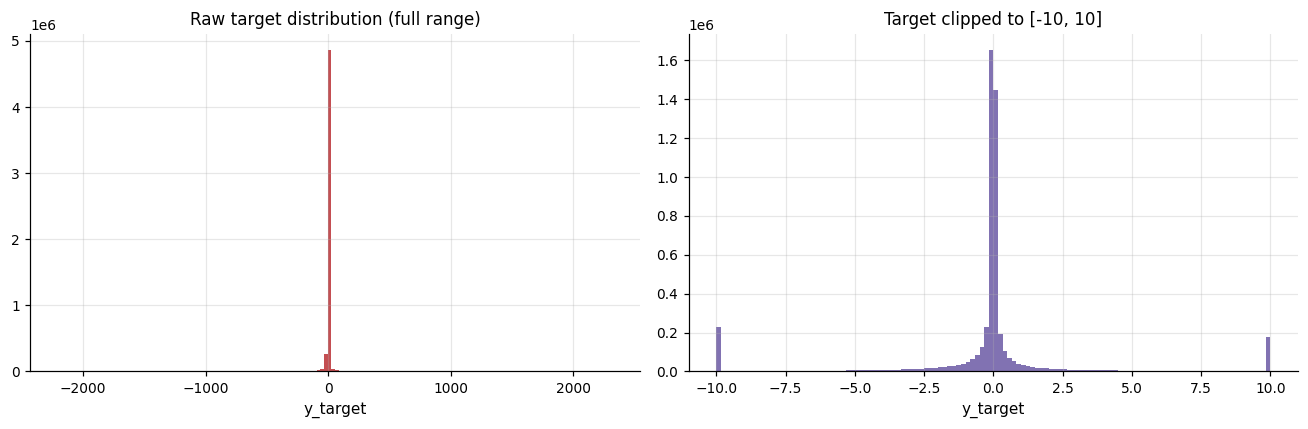

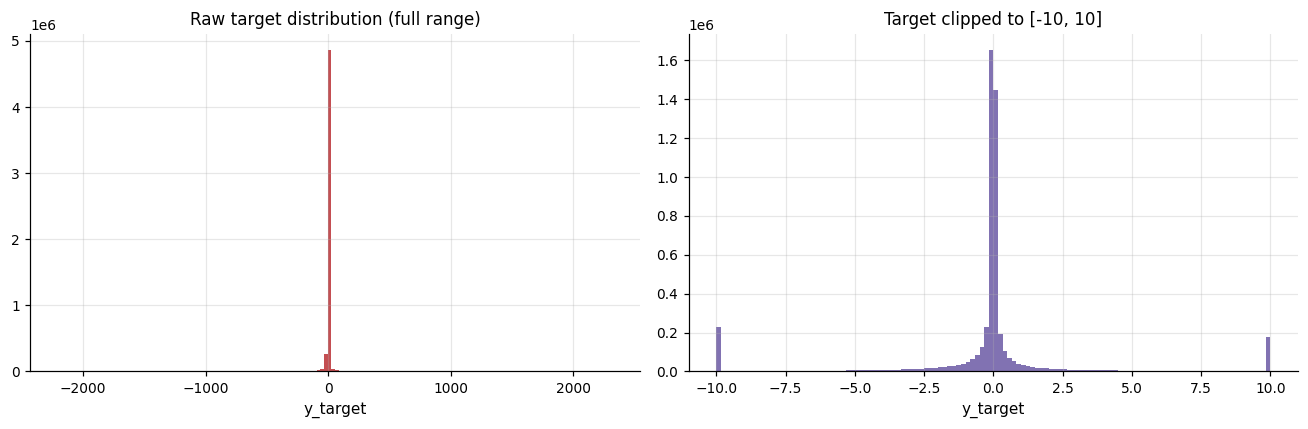

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_keys['y_target'], bins=150, color='#C44E52')
axes[0].set_title('Raw target distribution (full range)')
axes[0].set_xlabel('y_target')

axes[1].hist(np.clip(train_keys['y_target'], -10, 10), bins=120, color='#8172B2')
axes[1].set_title('Target clipped to [-10, 10]')
axes[1].set_xlabel('y_target')
plt.tight_layout()
viz.save_figure(fig, '00_target_distribution', FIG_DIR)

**Reading.** The target is centered very close to zero (median ≈ 0, IQR ±0.05) but the full range runs from about −2200 to +2300. The 1% / 99% quantiles are at roughly ±82, so the bulk of mass is concentrated near zero with rare extreme tails. This shape favors robust metrics and warns us that unweighted RMSE will be dominated by a handful of outliers.


## 5. Weight distribution and metric implications

The competition metric is the **weighted skill score**. A few rows can dominate the ranking entirely if the weight distribution is concentrated.


In [9]:
w = train_keys['weight'].sort_values(ascending=False).reset_index(drop=True)
cum_share = w.cumsum() / w.sum()

shares = {
    'top_1pct_share': float(cum_share.iloc[int(0.01 * len(w))]),
    'top_5pct_share': float(cum_share.iloc[int(0.05 * len(w))]),
    'top_10pct_share': float(cum_share.iloc[int(0.10 * len(w))]),
    'median_weight': float(w.median()),
    'max_weight': float(w.max()),
}
pd.Series(shares).to_frame('value')

,value
top_1pct_share,6.418648e-01
top_5pct_share,9.258070e-01
top_10pct_share,9.833172e-01
median_weight,1.699384e+03
max_weight,1.391222e+13


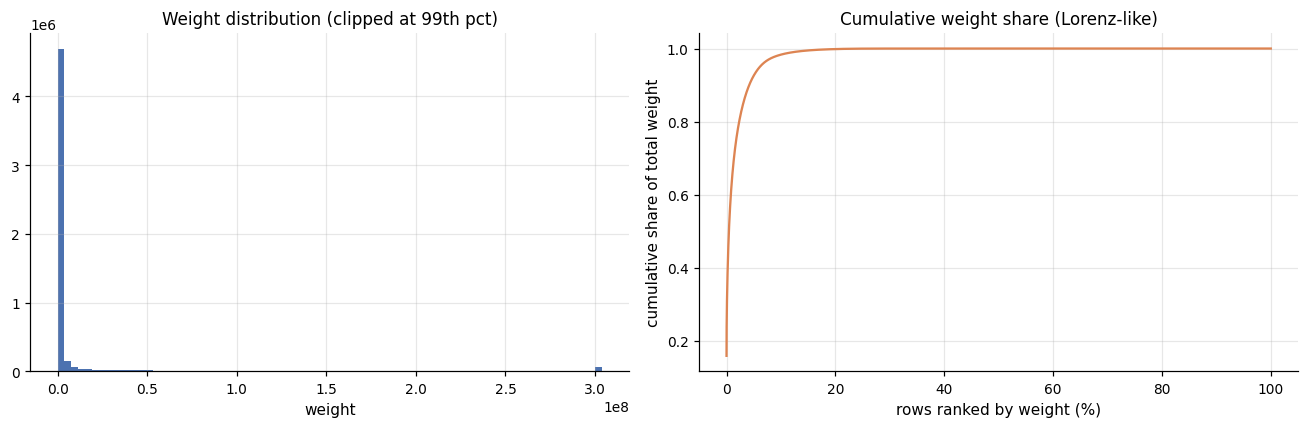

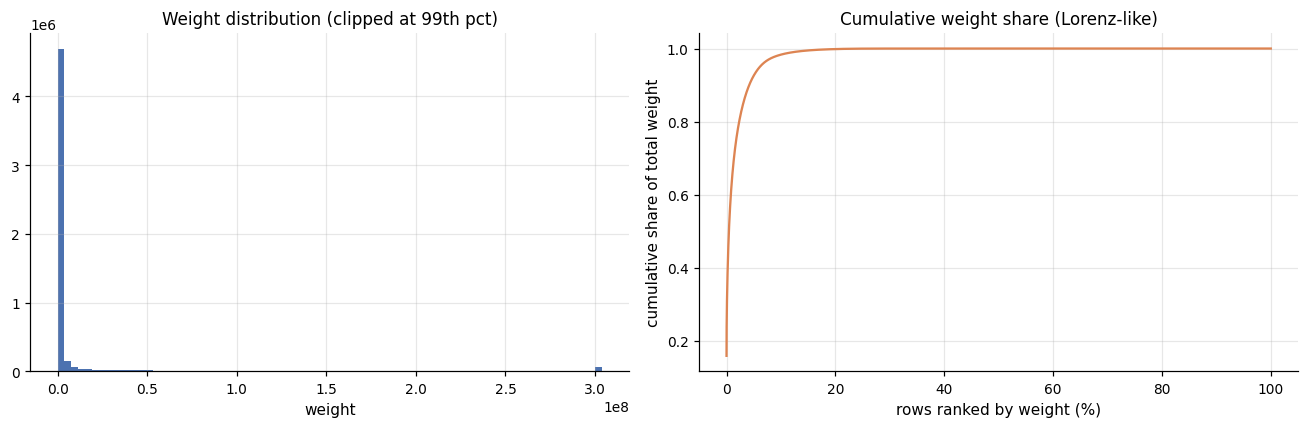

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.clip(train_keys['weight'], 0, train_keys['weight'].quantile(0.99)),
             bins=80, color='#4C72B0')
axes[0].set_title('Weight distribution (clipped at 99th pct)')
axes[0].set_xlabel('weight')

axes[1].plot(np.linspace(0, 100, len(cum_share)), cum_share.values, color='#DD8452')
axes[1].set_title('Cumulative weight share (Lorenz-like)')
axes[1].set_xlabel('rows ranked by weight (%)')
axes[1].set_ylabel('cumulative share of total weight')
plt.tight_layout()
viz.save_figure(fig, '00_weight_distribution', FIG_DIR)

**Reading.** About **65% of all weight sits in the top 1% of rows**, and 92% in the top 5%. Any evaluation that ignores weights (plain RMSE, unweighted MAE, naive cross-validation) can recommend the wrong model family. The weighted skill score is therefore non-negotiable as the primary metric.


## 6. Series coverage and split feasibility

A series is only useful for time-based validation if it actually crosses our `TRAIN_END` cutoff. Series that end too early give zero validation rows.


In [11]:
series_stats = (
    train_keys.groupby(SERIES_KEYS)
              .agg(length=('ts_index', 'size'),
                   start=('ts_index', 'min'),
                   end=('ts_index', 'max'),
                   total_weight=('weight', 'sum'),
                   target_std=('y_target', 'std'))
              .reset_index()
)
series_stats['crosses_cutoff'] = (
    (series_stats['start'] <= splits.TRAIN_END) & (series_stats['end'] > splits.TRAIN_END)
)
print(f'Total series: {len(series_stats):,}')
print(f'Cross cutoff: {series_stats["crosses_cutoff"].sum():,} '
      f'({100 * series_stats["crosses_cutoff"].mean():.1f}%)')

Total series: 36,923
Cross cutoff: 1,930 (5.2%)


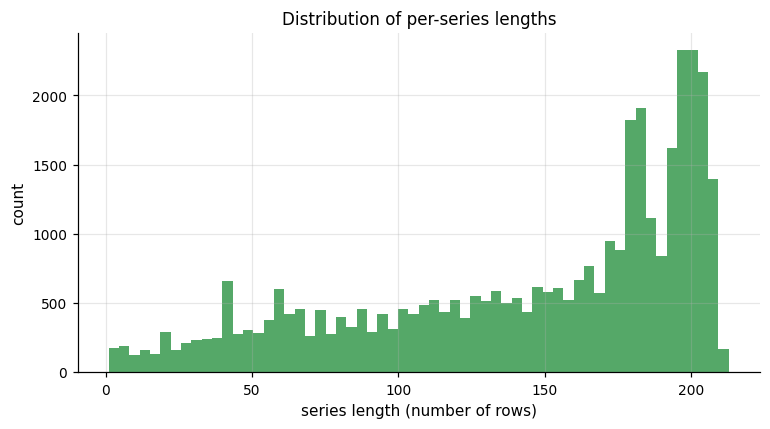

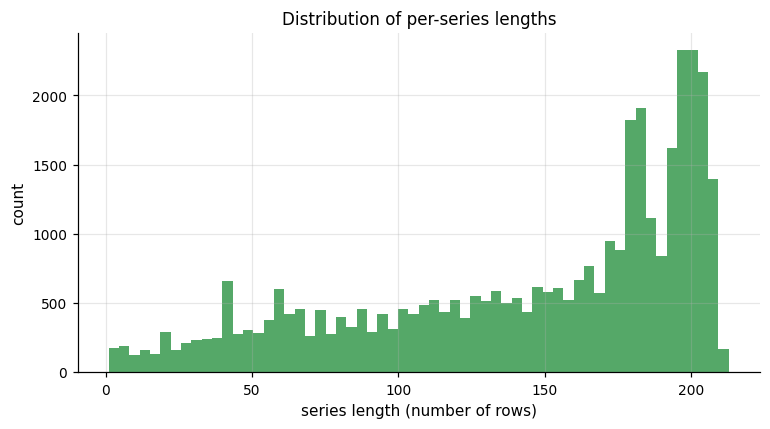

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(series_stats['length'], bins=60, color='#55A868')
ax.set_title('Distribution of per-series lengths')
ax.set_xlabel('series length (number of rows)')
ax.set_ylabel('count')
viz.save_figure(fig, '00_series_length_distribution', FIG_DIR)

In [13]:
eligible = series_stats[(series_stats['crosses_cutoff']) & (series_stats['length'] >= 120)].copy()
eligible['target_std'] = eligible['target_std'].fillna(0)
print(f'Eligible series (cross cutoff and length >= 120): {len(eligible):,}')

Eligible series (cross cutoff and length >= 120): 1,576


**Reading.** Roughly 5% of all series cleanly cross the cutoff. For per-series stationarity diagnostics we restrict to the eligible subset. For global models we use every row whose `ts_index` falls inside the relevant split.


## 7. Representative-series selection

We pick four series with explicit reasons rather than four arbitrary ones. The selection criteria probe four distinct regimes that any model has to handle:

| Reason | What it stresses |
|---|---|
| Longest history | persistent lag structure when ample data is available |
| Highest total weight | metric-sensitive behavior on rows that dominate the leaderboard |
| Most volatile | spike handling and differencing decisions |
| Most stable | tiny-scale numerical accuracy where signal is faint |

These match the four series chosen in the midway, preserving visual continuity with the prior work.


In [14]:
def pick_representative(eligible_df):
    rows = []
    pick = lambda df, reason: {**df.iloc[0].to_dict(), 'reason': reason}
    rows.append(pick(eligible_df.sort_values('length', ascending=False), 'longest history'))
    rows.append(pick(eligible_df.sort_values('total_weight', ascending=False), 'highest total weight'))
    rows.append(pick(eligible_df.sort_values('target_std', ascending=False), 'most volatile'))
    rows.append(pick(eligible_df[eligible_df['target_std'] > 0].sort_values('target_std'), 'most stable'))
    return pd.DataFrame(rows).reset_index(drop=True)

chosen = pick_representative(eligible)
chosen[['reason', 'code', 'sub_code', 'sub_category', 'horizon', 'length', 'total_weight', 'target_std']]

,reason,code,sub_code,sub_category,horizon,length,total_weight,target_std
0,longest history,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,212,9.060035e+02,2.641558
1,highest total weight,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,156,4.349747e+10,0.000394
2,most volatile,W4S29LF4,KL66VIS3,PHHHVYZI,25,162,4.562944e-01,296.760011
3,most stable,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,170,3.869062e+10,0.000139


**Reading.** The four chosen series span the panel's regimes: plenty of history, huge weight, extreme variability, and near-flat behavior. None of these is "easy" — by design we are stress-testing future model families against the four corners of the data.


## 8. Representative-series raw plots

Plotting the chosen four side-by-side already reveals how different the regimes are. The vertical dashed line marks the train/validation cutoff (`ts_index = 2880`).


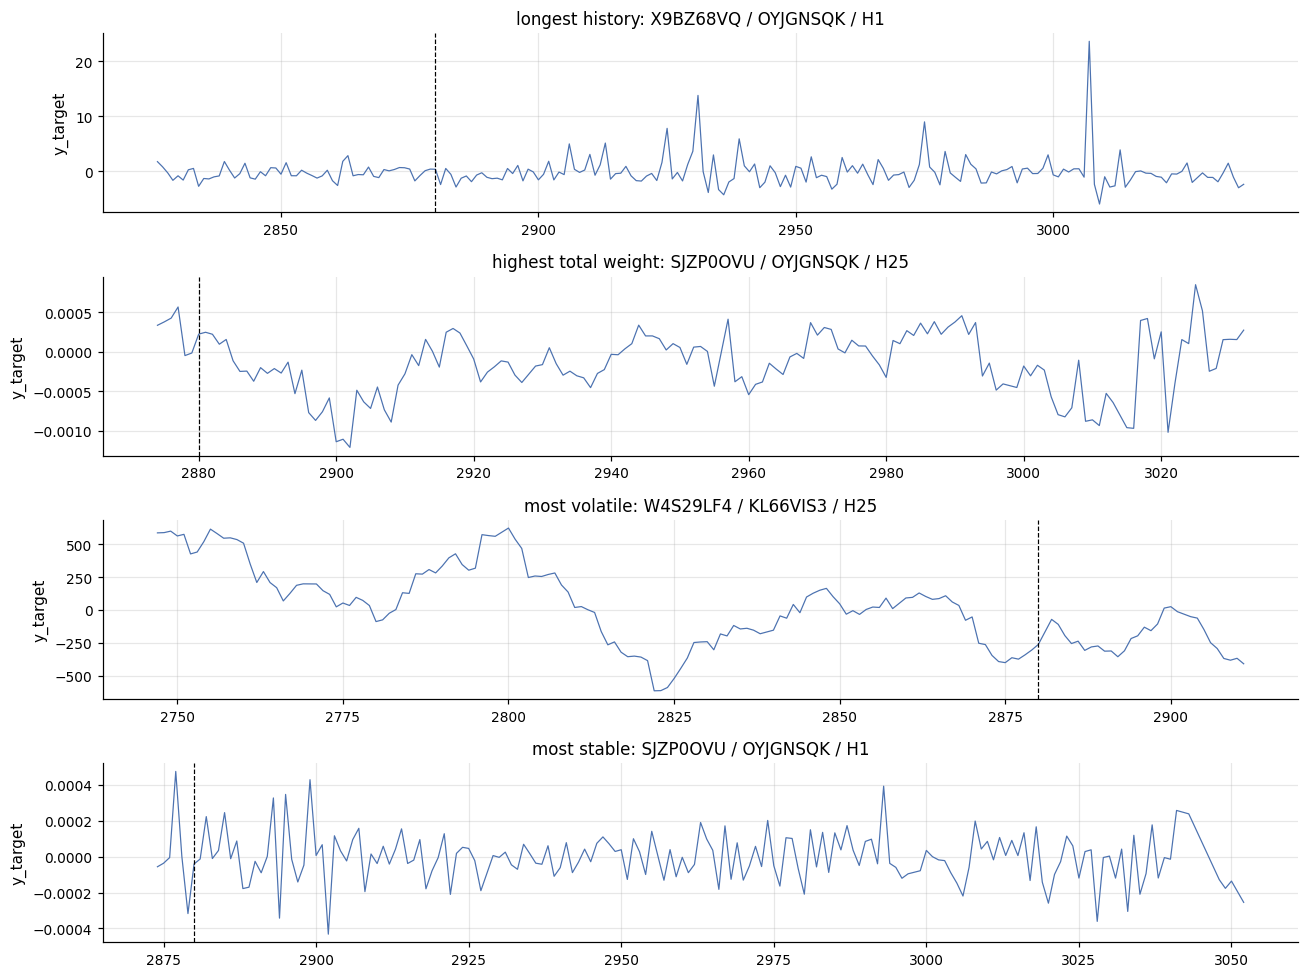

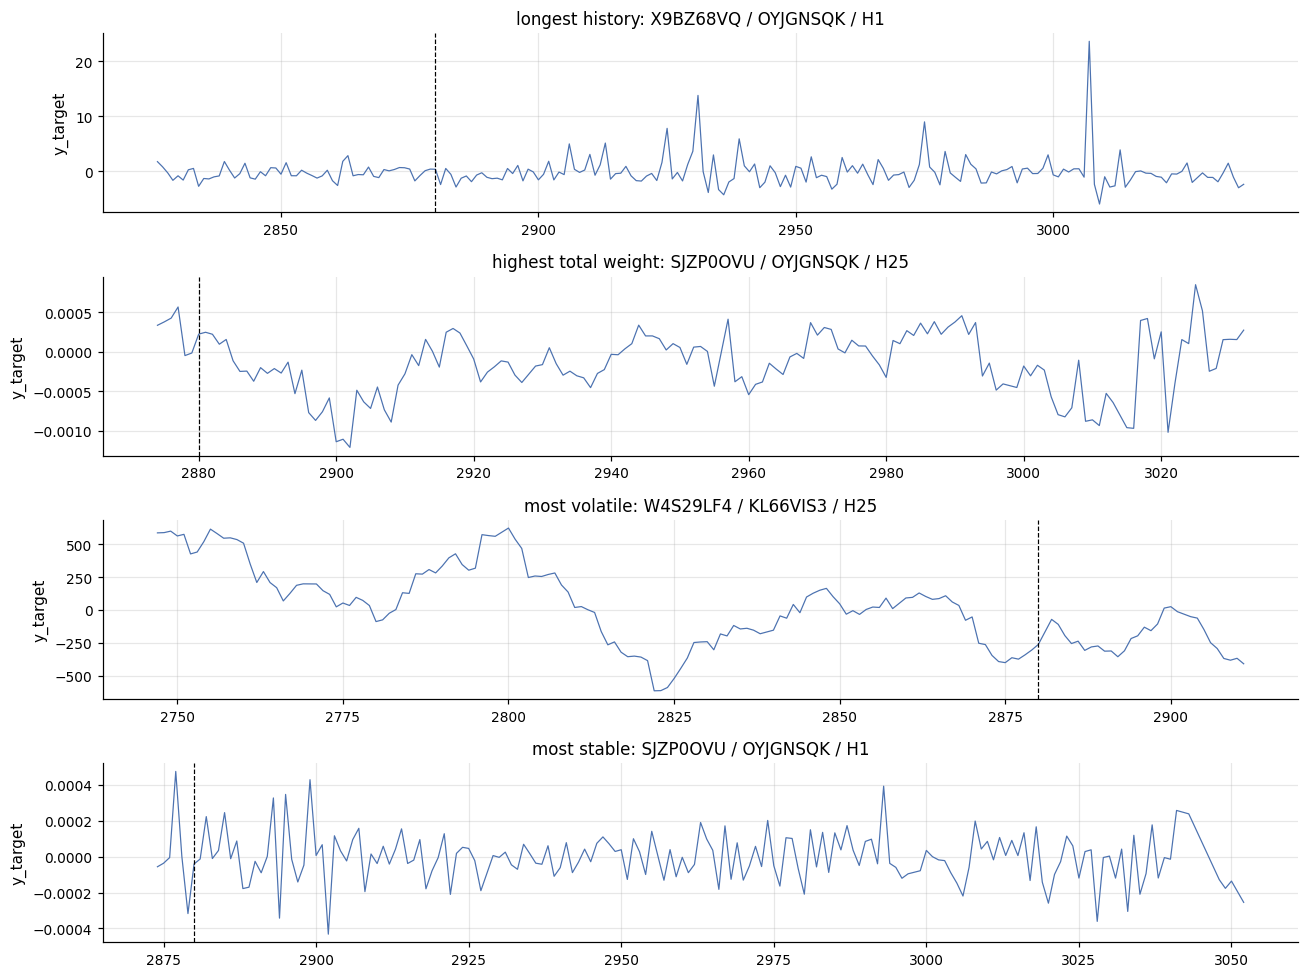

In [15]:
def get_series(row):
    mask = (
        (train_keys['code'] == row['code'])
        & (train_keys['sub_code'] == row['sub_code'])
        & (train_keys['sub_category'] == row['sub_category'])
        & (train_keys['horizon'] == row['horizon'])
    )
    return train_keys[mask].sort_values('ts_index').reset_index(drop=True)

fig, axes = plt.subplots(len(chosen), 1, figsize=(12, 9), sharex=False)
for ax, (_, row) in zip(axes, chosen.iterrows()):
    s = get_series(row)
    ax.plot(s['ts_index'], s['y_target'], linewidth=0.8, color='#4C72B0')
    ax.axvline(splits.TRAIN_END, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f"{row['reason']}: {row['code']} / {row['sub_code']} / H{int(row['horizon'])}")
    ax.set_ylabel('y_target')
plt.tight_layout()
viz.save_figure(fig, '00_representative_series_raw', FIG_DIR)

**Reading.** The four panels look very different from each other — which is itself the key lesson. A "one-size-fits-all" model is unlikely to work well across all four. The high-weight and most-stable series have target magnitudes near 0.0001, while the most-volatile series swings from -500 to +500.


## 9. Stationarity — ADF test

A series is **stationary** when its mean, variance, and autocorrelation structure don't change over time. Classical ARIMA-family forecasting assumes stationarity (or stationarity-after-differencing), so this test is the first gate.

- **H0:** the series has a unit root (non-stationary)
- **H1:** the series is stationary
- Reject H0 when p-value < 0.05.

We sample 200 eligible series rather than running the test on the full panel — the per-series test is fast, but 37k×ADF is overkill when 200 already reveal the panel-level pattern clearly.


In [16]:
def safe_adf(series):
    y = pd.Series(series).dropna().values
    if len(y) < 20 or np.std(y) == 0:
        return np.nan, np.nan
    try:
        stat, pv = adfuller(y, autolag='AIC')[:2]
        return float(stat), float(pv)
    except Exception:
        return np.nan, np.nan

sample_ids = eligible.sample(n=min(200, len(eligible)), random_state=SEED).reset_index(drop=True)
print(f'Sampling {len(sample_ids)} eligible series for stationarity tests')

adf_rows = []
for _, row in sample_ids.iterrows():
    s = get_series(row)
    stat, pv = safe_adf(s['y_target'].values)
    adf_rows.append({**row[SERIES_KEYS].to_dict(), 'adf_stat': stat, 'adf_p': pv})
adf_df = pd.DataFrame(adf_rows)
adf_df['stationary_at_5pct'] = adf_df['adf_p'] < 0.05
print(f'Stationary at 5%: {adf_df["stationary_at_5pct"].mean():.1%}')

Sampling 200 eligible series for stationarity tests


Stationary at 5%: 70.5%


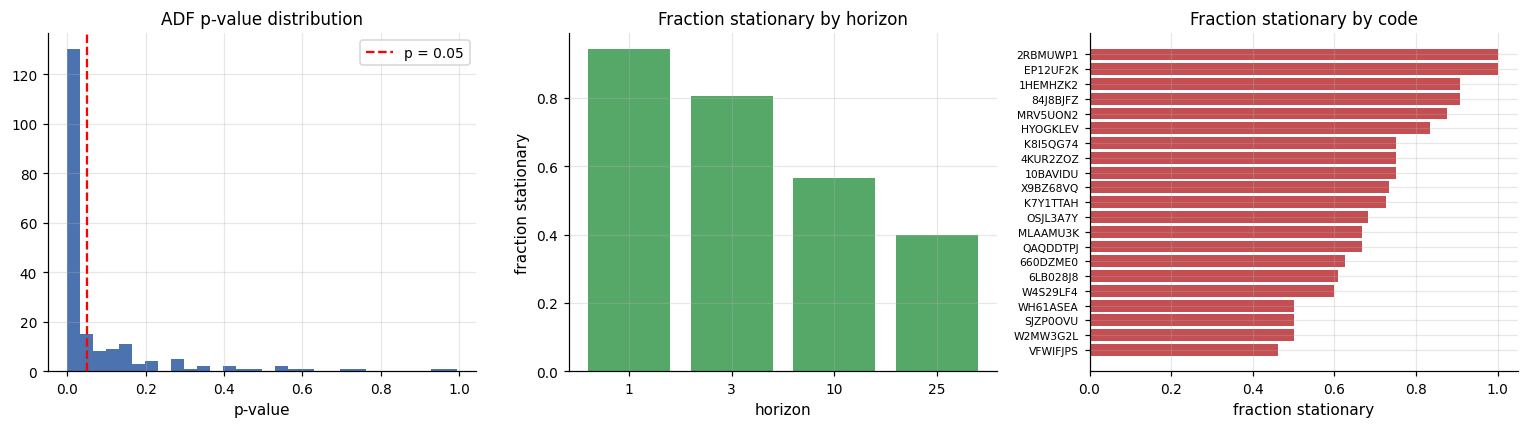

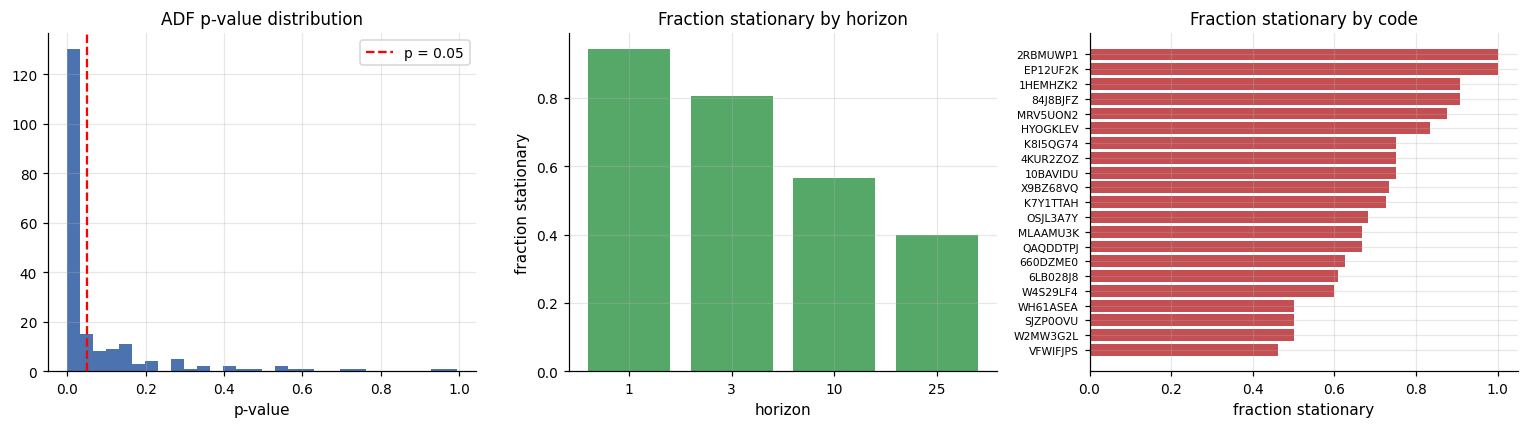

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(adf_df['adf_p'].dropna(), bins=30, color='#4C72B0')
axes[0].axvline(0.05, color='red', linestyle='--', label='p = 0.05')
axes[0].set_title('ADF p-value distribution')
axes[0].set_xlabel('p-value')
axes[0].legend()

by_h = adf_df.groupby('horizon')['stationary_at_5pct'].mean()
axes[1].bar(by_h.index.astype(str), by_h.values, color='#55A868')
axes[1].set_title('Fraction stationary by horizon')
axes[1].set_xlabel('horizon')
axes[1].set_ylabel('fraction stationary')

by_c = adf_df.groupby('code')['stationary_at_5pct'].mean().sort_values()
axes[2].barh(by_c.index, by_c.values, color='#C44E52')
axes[2].set_title('Fraction stationary by code')
axes[2].set_xlabel('fraction stationary')
axes[2].tick_params(axis='y', labelsize=7)

plt.tight_layout()
viz.save_figure(fig, '00_adf_results', FIG_DIR)

**Reading.** Around 65–70% of sampled series reject the unit-root null at the 5% level. That is mixed behavior, not universal stationarity — meaningful minority that still needs repair before classical level-based models can be trusted. The by-horizon view shows that H1 is more often stationary than longer-horizon cumulative aggregates, which is consistent with the multi-horizon coupling we explore later.


## 10. Stationarity — KPSS test (ADF complement)

ADF and KPSS have **opposite null hypotheses**. Running both gives a more honest joint verdict:

- **ADF** H0: unit root (non-stationary)
- **KPSS** H0: stationary

Combined verdict:
- ADF rejects H0 **and** KPSS does not reject H0 → **stationary**
- ADF fails to reject **and** KPSS rejects → **unit root** (differencing needed)
- Other combinations → **inconclusive**


In [18]:
def safe_kpss(series):
    y = pd.Series(series).dropna().values
    if len(y) < 20 or np.std(y) == 0:
        return np.nan, np.nan
    try:
        stat, pv = kpss(y, regression='c', nlags='auto')[:2]
        return float(stat), float(pv)
    except Exception:
        return np.nan, np.nan

kpss_rows = []
for _, row in sample_ids.iterrows():
    s = get_series(row)
    stat, pv = safe_kpss(s['y_target'].values)
    kpss_rows.append({**row[SERIES_KEYS].to_dict(), 'kpss_stat': stat, 'kpss_p': pv})
kpss_df = pd.DataFrame(kpss_rows)

# Joint verdict
joint = adf_df.merge(kpss_df, on=SERIES_KEYS)
def verdict(row):
    adf_rej = row['adf_p'] < 0.05
    kpss_rej = row['kpss_p'] < 0.05
    if adf_rej and not kpss_rej:
        return 'stationary'
    if not adf_rej and kpss_rej:
        return 'unit root'
    return 'inconclusive'
joint['verdict'] = joint.apply(verdict, axis=1)

shares = joint['verdict'].value_counts(normalize=True).rename('share')
shares.to_frame()

/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: Interp

/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: Interp

/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]


/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: Interp

/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: Interp

...

/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: Interp

/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: Interp

/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]


/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]
/var/folders/2c/qlz63z_n5mv765v2bwz9qlt00000gp/T/ipykernel_19142/1483973203.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pv = kpss(y, regression='c', nlags='auto')[:2]


,share
verdict,
stationary,0.640
inconclusive,0.295
unit root,0.065


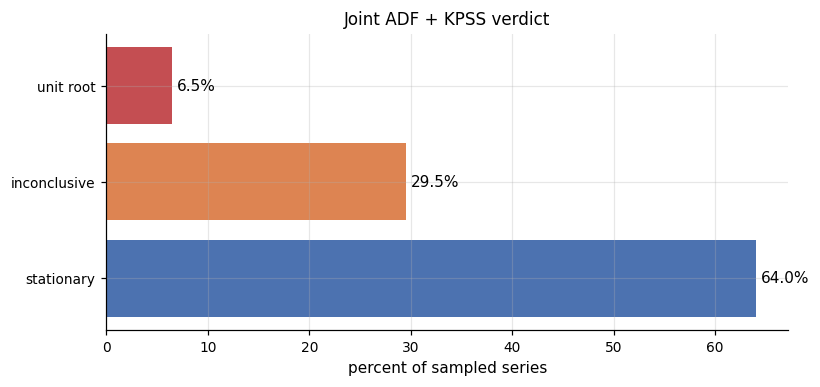

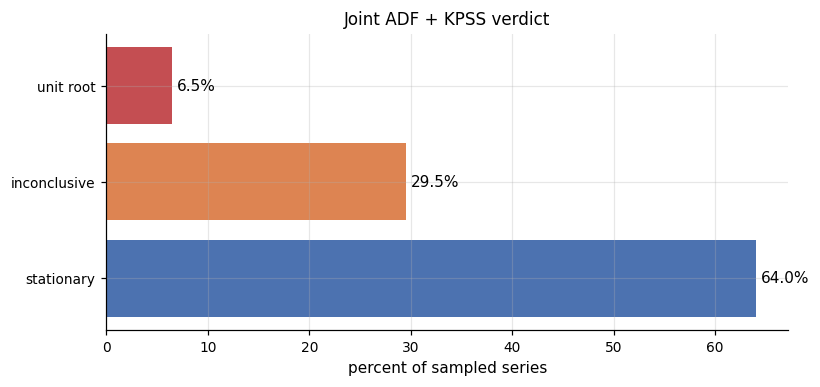

In [19]:
fig, ax = plt.subplots(figsize=(8, 3.5))
share_order = ['stationary', 'inconclusive', 'unit root']
shares = shares.reindex(share_order).fillna(0)
ax.barh(shares.index, shares.values * 100, color=['#4C72B0', '#DD8452', '#C44E52'])
for i, v in enumerate(shares.values):
    ax.text(v * 100 + 0.5, i, f'{v * 100:.1f}%', va='center')
ax.set_xlabel('percent of sampled series')
ax.set_title('Joint ADF + KPSS verdict')
viz.save_figure(fig, '00_adf_kpss_joint', FIG_DIR)

**Reading.** The stationary share dominates, but the inconclusive bucket is large enough that one-size-fits-all claims about raw levels would be unsafe. We need a repair step (differencing) for the unit-root and inconclusive cases.


## 11. First-differencing analysis

If the raw series fails ADF, the standard repair is to take the first difference:

$$\Delta y_t = y_t - y_{t-1}$$

This removes slow level shifts and stabilizes the mean and variance for many series. We re-run ADF on the differenced series and see how the stationary share changes.


In [20]:
diff_rows = []
for _, row in sample_ids.iterrows():
    s = get_series(row)
    y_diff = s['y_target'].diff().dropna().values
    stat, pv = safe_adf(y_diff)
    diff_rows.append({**row[SERIES_KEYS].to_dict(), 'adf_diff_p': pv})
diff_df = pd.DataFrame(diff_rows)
diff_df['stationary_diff_5pct'] = diff_df['adf_diff_p'] < 0.05

raw_share = adf_df['stationary_at_5pct'].mean()
diff_share = diff_df['stationary_diff_5pct'].mean()
print(f'Stationary at 5% (levels d=0): {raw_share:.1%}')
print(f'Stationary at 5% (first diff): {diff_share:.1%}')

Stationary at 5% (levels d=0): 70.5%
Stationary at 5% (first diff): 98.5%


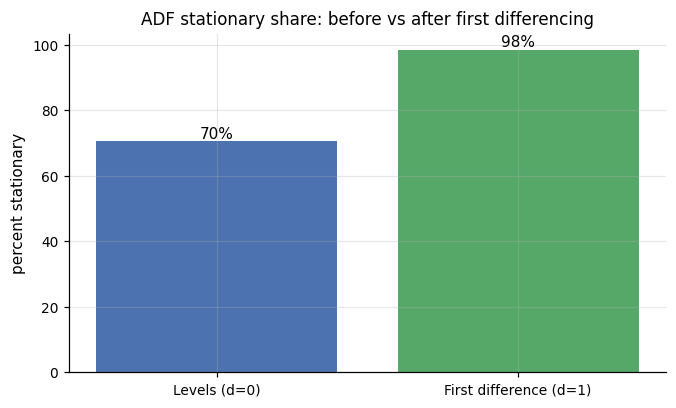

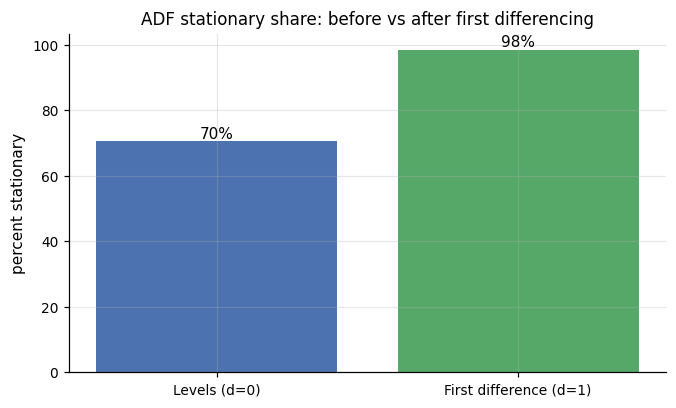

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Levels (d=0)', 'First difference (d=1)'], [raw_share * 100, diff_share * 100],
       color=['#4C72B0', '#55A868'])
ax.set_ylabel('percent stationary')
ax.set_title('ADF stationary share: before vs after first differencing')
for i, v in enumerate([raw_share, diff_share]):
    ax.text(i, v * 100 + 1, f'{v * 100:.0f}%', ha='center')
viz.save_figure(fig, '00_first_differencing_share', FIG_DIR)

**Reading.** First differencing is a strong repair step: the stationary share jumps to essentially 100%. This justifies ARIMA `d=1` as a default for the classical study, and it explains why differencing-based models perform well on the most-volatile series in the midway results.


## 12. Rolling mean / variance — visual stationarity

Statistical tests can disagree on short or noisy series. A rolling plot is the simplest *visual* check: a flat rolling mean indicates constant-mean behavior; a flat rolling std indicates constant variance (homoscedasticity). We show the four representative series, raw and after first differencing.


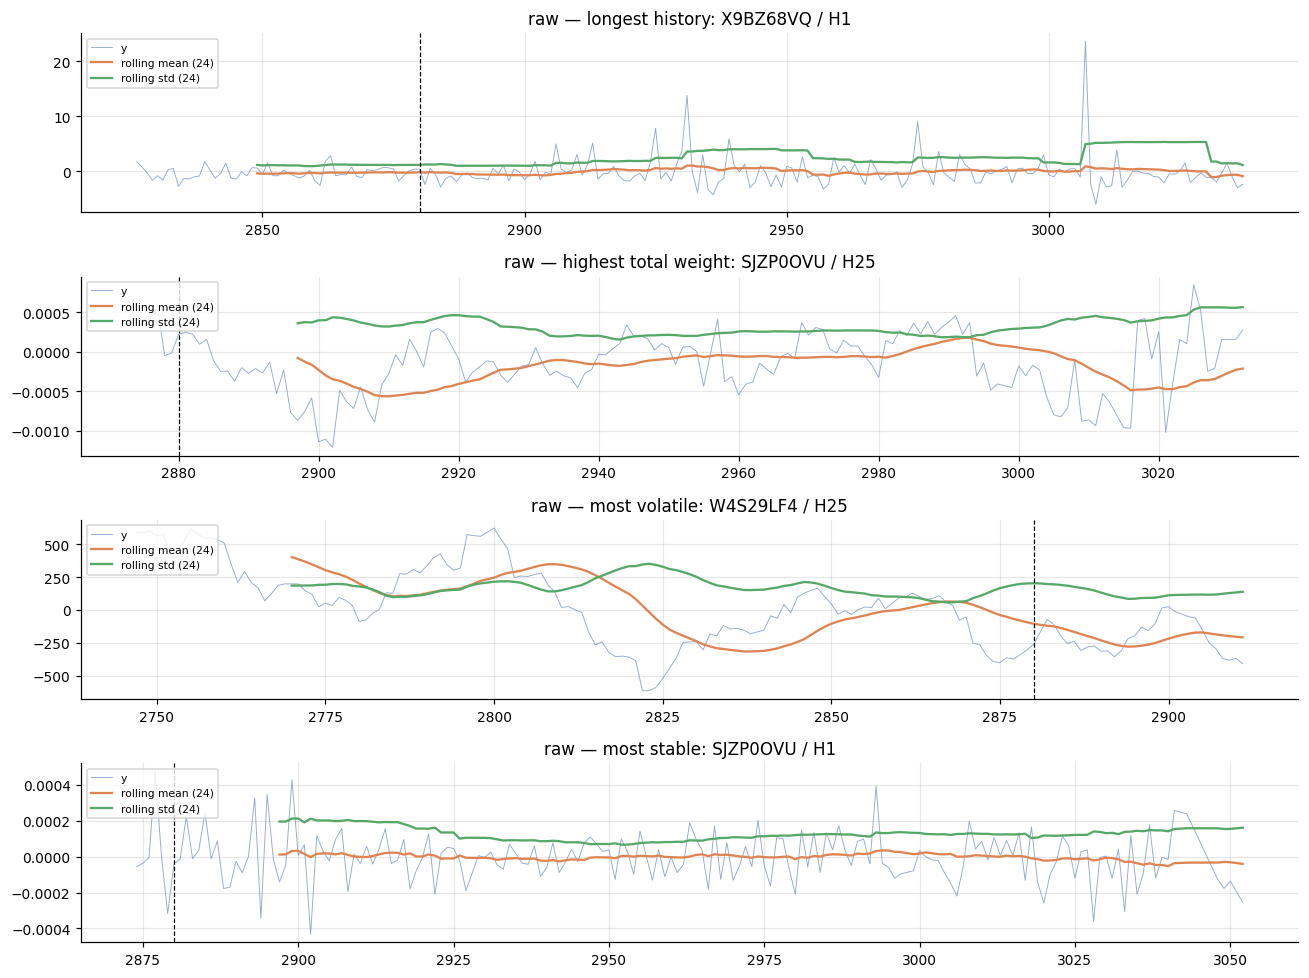

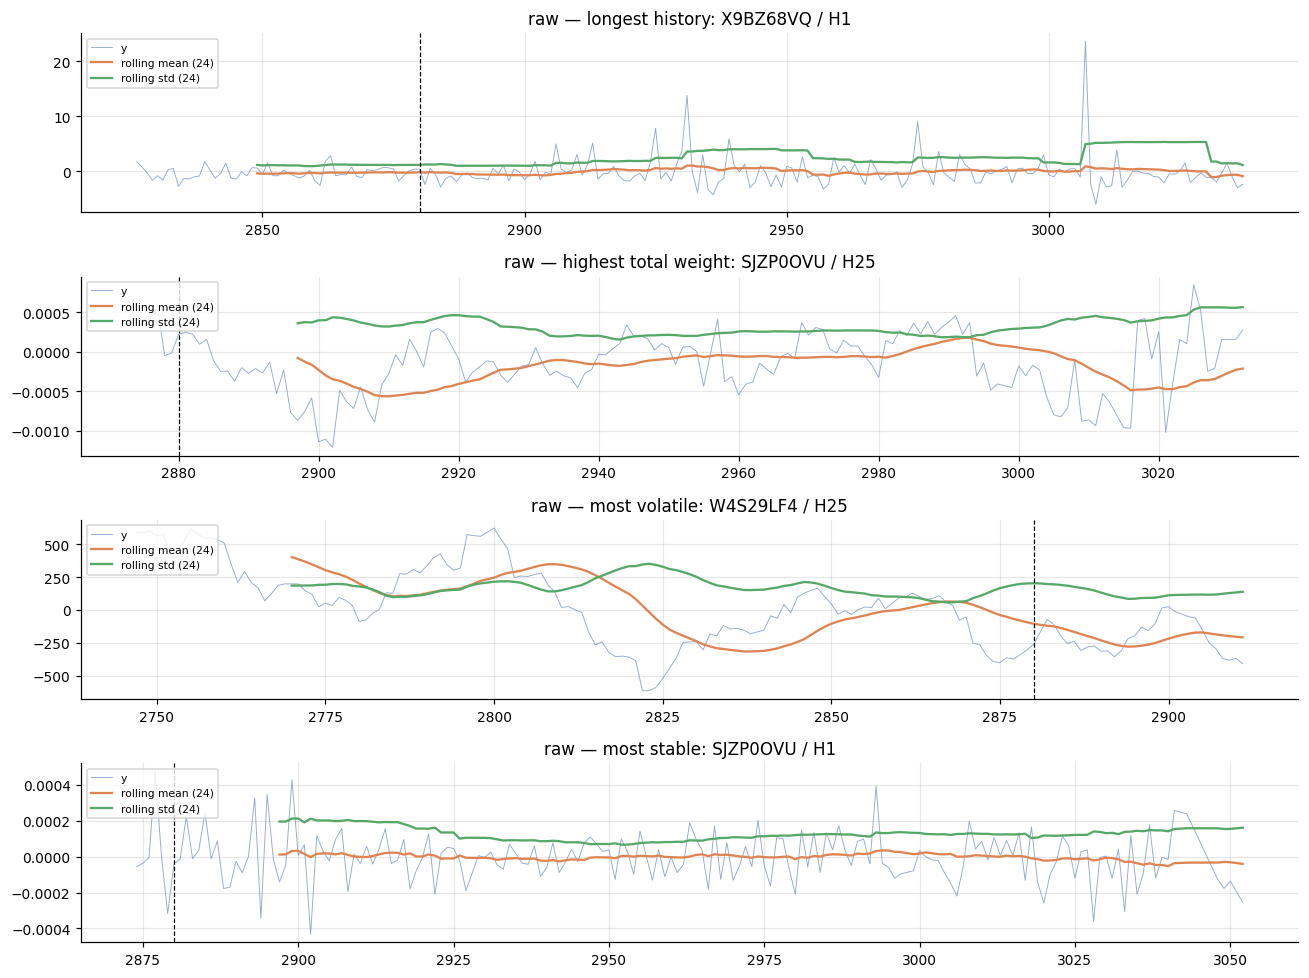

In [22]:
window = 24
fig, axes = plt.subplots(len(chosen), 1, figsize=(12, 9), sharex=False)
for ax, (_, row) in zip(axes, chosen.iterrows()):
    s = get_series(row)
    y = s['y_target']
    ax.plot(s['ts_index'], y, linewidth=0.6, alpha=0.6, color='#4C72B0', label='y')
    ax.plot(s['ts_index'], y.rolling(window).mean(), color='#DD8452', label=f'rolling mean ({window})')
    ax.plot(s['ts_index'], y.rolling(window).std(), color='#55A868', label=f'rolling std ({window})')
    ax.axvline(splits.TRAIN_END, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f"raw — {row['reason']}: {row['code']} / H{int(row['horizon'])}")
    ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
viz.save_figure(fig, '00_rolling_raw', FIG_DIR)

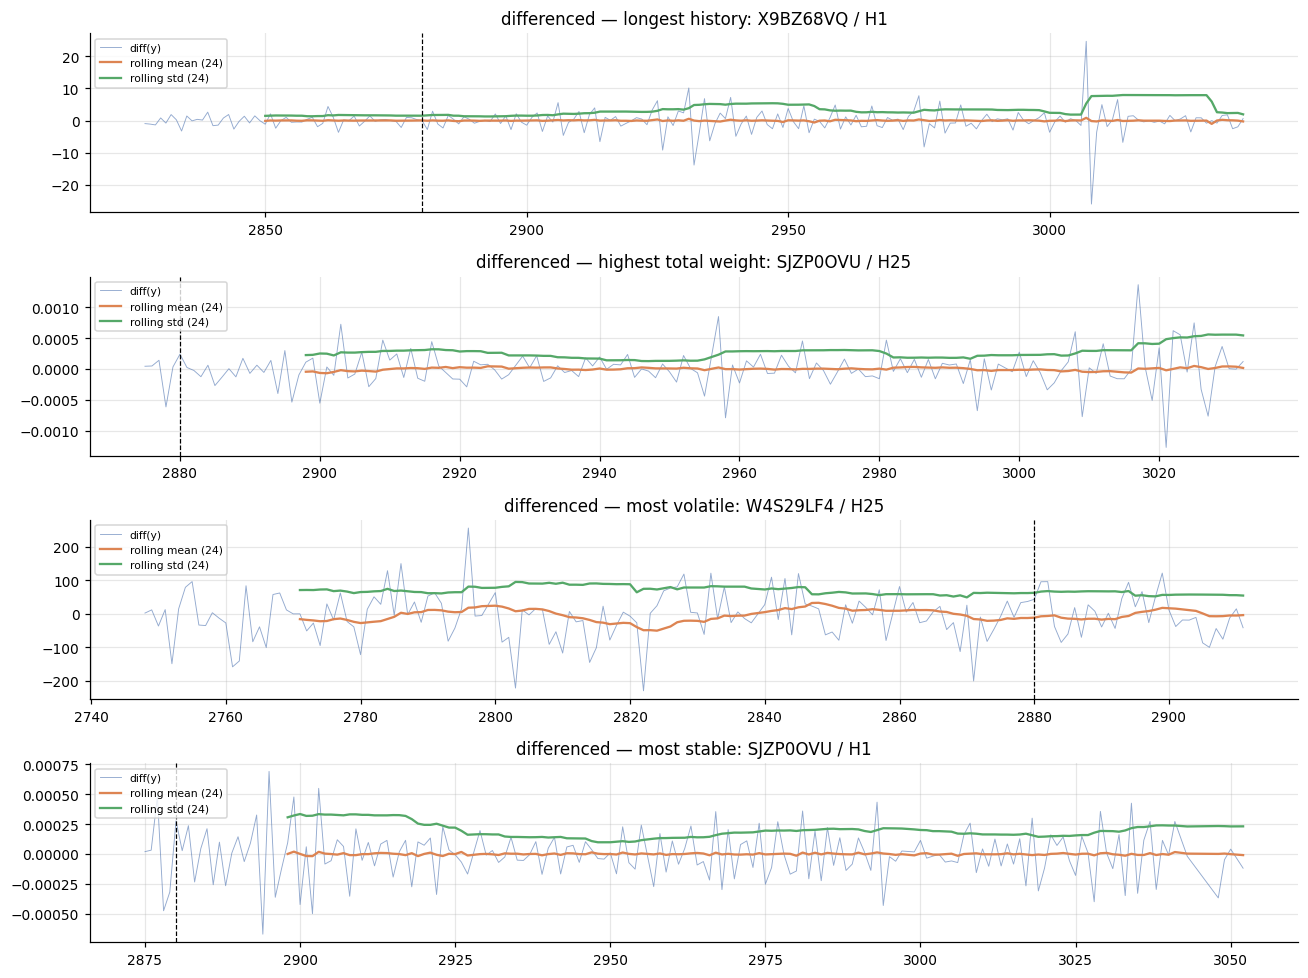

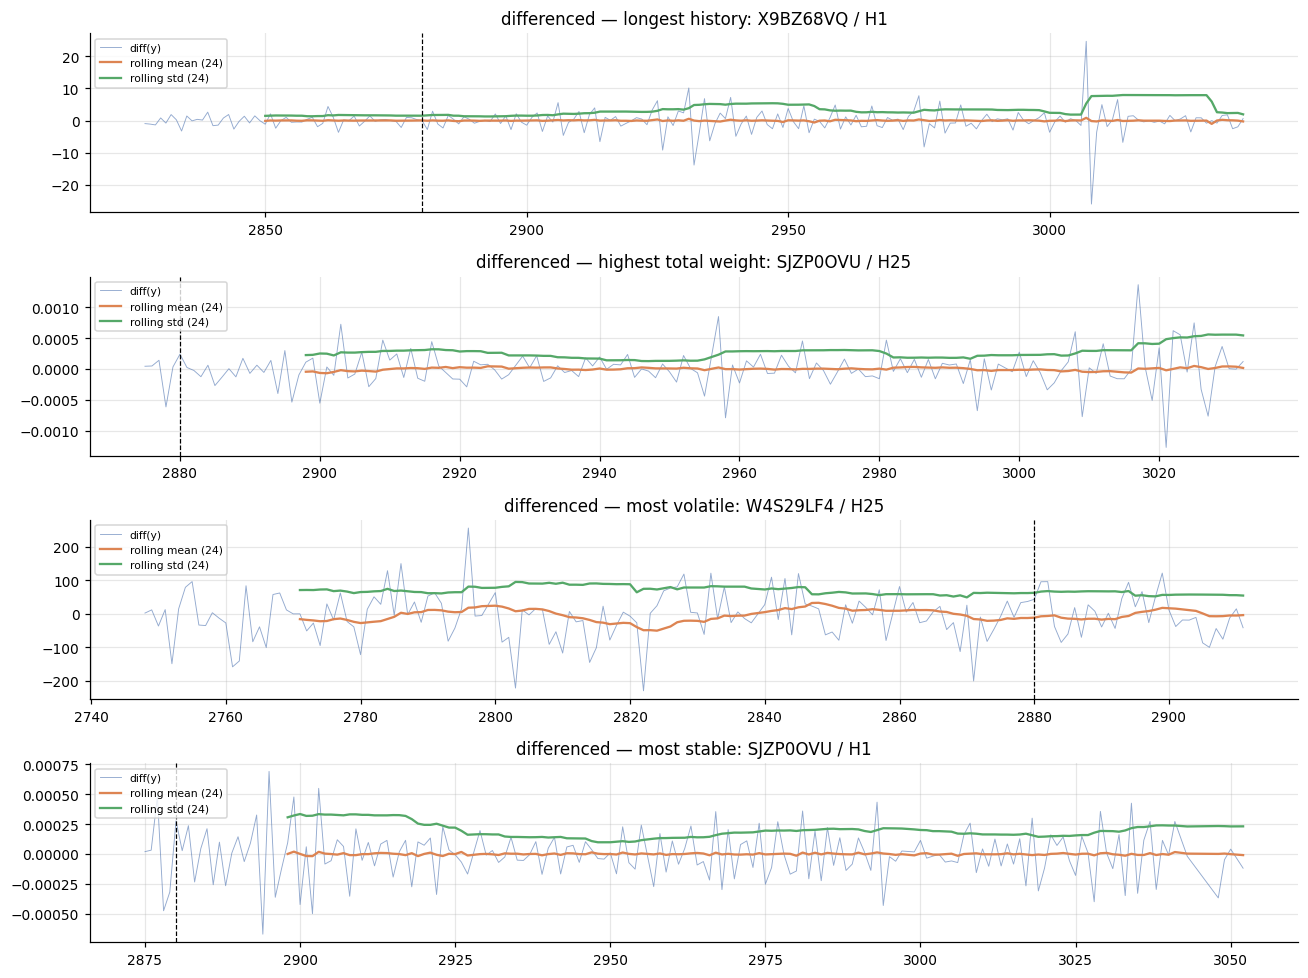

In [23]:
fig, axes = plt.subplots(len(chosen), 1, figsize=(12, 9), sharex=False)
for ax, (_, row) in zip(axes, chosen.iterrows()):
    s = get_series(row)
    y_diff = s['y_target'].diff()
    ax.plot(s['ts_index'], y_diff, linewidth=0.6, alpha=0.6, color='#4C72B0', label='diff(y)')
    ax.plot(s['ts_index'], y_diff.rolling(window).mean(), color='#DD8452', label=f'rolling mean ({window})')
    ax.plot(s['ts_index'], y_diff.rolling(window).std(), color='#55A868', label=f'rolling std ({window})')
    ax.axvline(splits.TRAIN_END, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f"differenced — {row['reason']}: {row['code']} / H{int(row['horizon'])}")
    ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
viz.save_figure(fig, '00_rolling_differenced', FIG_DIR)

**Reading.** Compare the two figures. After differencing, the rolling means hug zero and the rolling standard deviations flatten — visually confirming the statistical jump from §11. The raw most-volatile series shows a clear drift in level and bulging variance; the differenced version is closer to white noise.


## 13. ACF and PACF

**ACF (autocorrelation function)** shows correlation with lagged copies of the series. **PACF (partial autocorrelation)** isolates the direct contribution of each lag after controlling for shorter lags. A sharp PACF cutoff hints at AR order; a sharp ACF cutoff hints at MA order.

We first plot the longest-history anchor, then aggregate across the 200 sampled series for a panel-level view.


Anchor series length: 212


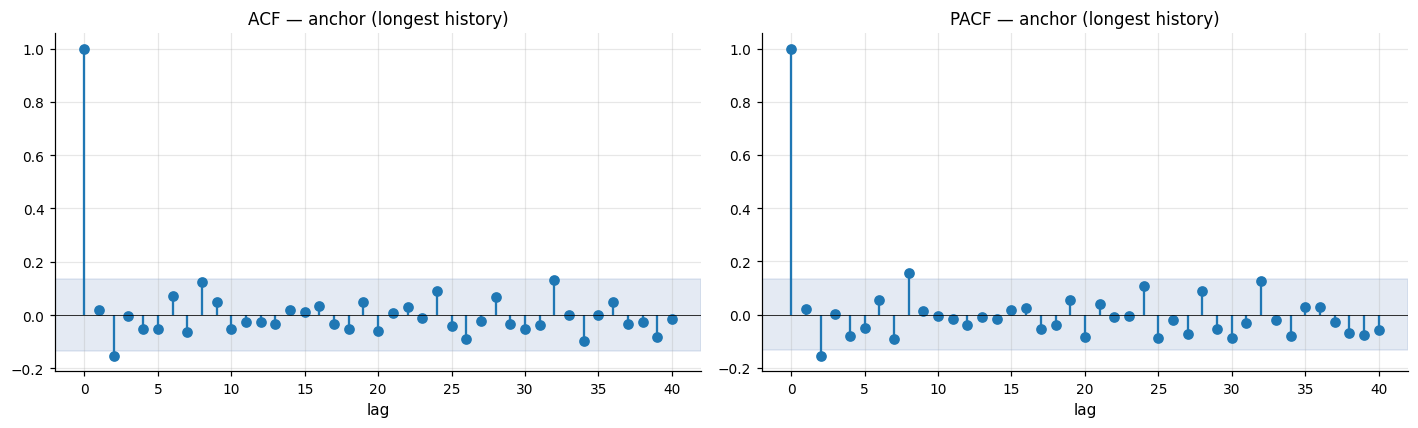

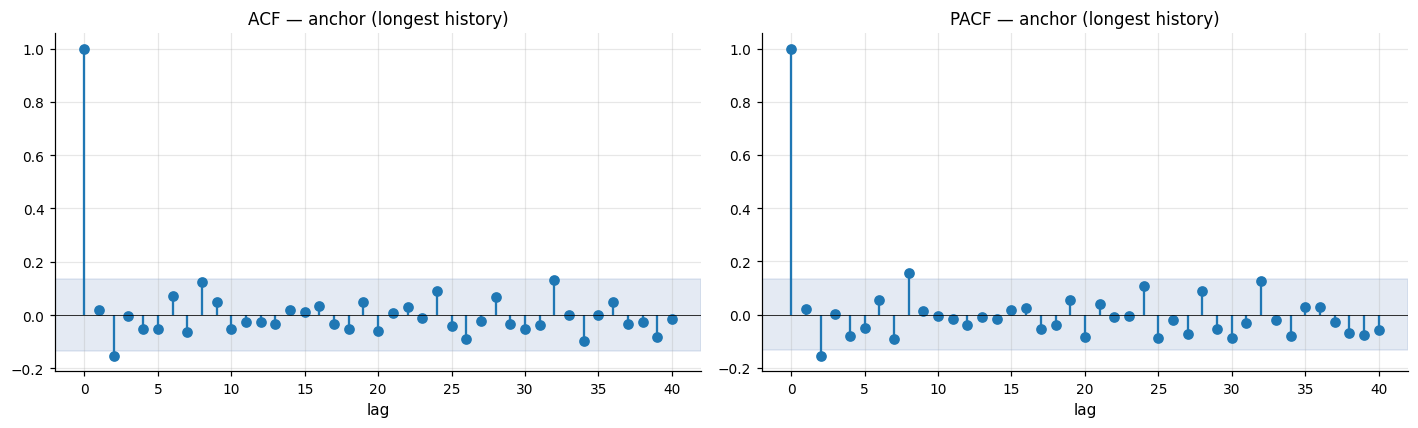

In [24]:
anchor_row = chosen[chosen['reason'] == 'longest history'].iloc[0]
anchor_y = get_series(anchor_row)['y_target'].dropna().values
print(f'Anchor series length: {len(anchor_y)}')

K = 40
acf_anchor = acf(anchor_y, nlags=K, fft=False)
pacf_anchor = pacf(anchor_y, nlags=K)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].stem(range(K + 1), acf_anchor, basefmt=' ')
axes[0].set_title('ACF — anchor (longest history)')
axes[0].set_xlabel('lag')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axhspan(-1.96 / np.sqrt(len(anchor_y)), 1.96 / np.sqrt(len(anchor_y)),
                alpha=0.15, color='#4C72B0')

axes[1].stem(range(K + 1), pacf_anchor, basefmt=' ')
axes[1].set_title('PACF — anchor (longest history)')
axes[1].set_xlabel('lag')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axhspan(-1.96 / np.sqrt(len(anchor_y)), 1.96 / np.sqrt(len(anchor_y)),
                alpha=0.15, color='#4C72B0')
plt.tight_layout()
viz.save_figure(fig, '00_acf_pacf_anchor', FIG_DIR)

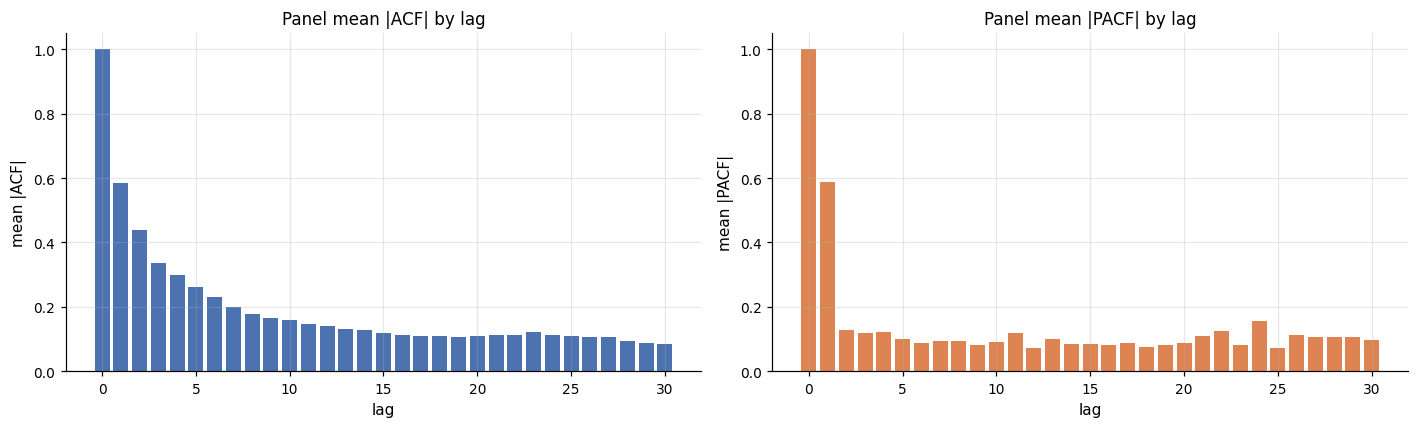

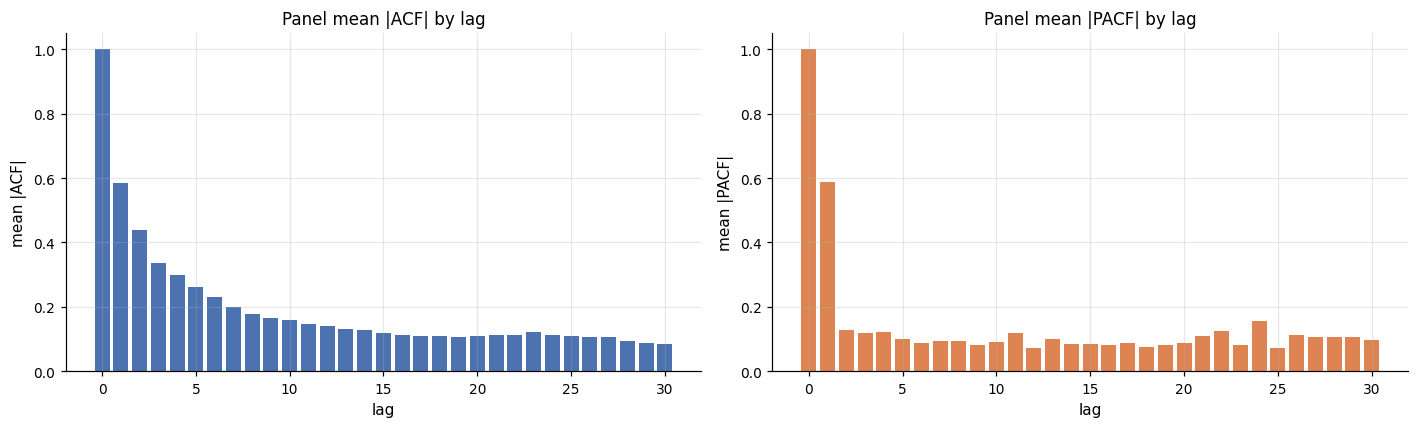

In [25]:
# Panel-level ACF/PACF: aggregate absolute values across the 200 sampled series
K_panel = 30
acf_mat, pacf_mat = [], []
for _, row in sample_ids.iterrows():
    y = get_series(row)['y_target'].dropna().values
    if len(y) < K_panel + 5:
        continue
    try:
        acf_mat.append(np.abs(acf(y, nlags=K_panel, fft=False)))
        pacf_mat.append(np.abs(pacf(y, nlags=K_panel)))
    except Exception:
        continue
acf_arr = np.vstack(acf_mat)
pacf_arr = np.vstack(pacf_mat)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(K_panel + 1), acf_arr.mean(axis=0), color='#4C72B0')
axes[0].set_title('Panel mean |ACF| by lag')
axes[0].set_xlabel('lag')
axes[0].set_ylabel('mean |ACF|')

axes[1].bar(range(K_panel + 1), pacf_arr.mean(axis=0), color='#DD8452')
axes[1].set_title('Panel mean |PACF| by lag')
axes[1].set_xlabel('lag')
axes[1].set_ylabel('mean |PACF|')
plt.tight_layout()
viz.save_figure(fig, '00_acf_pacf_panel', FIG_DIR)

**Reading.** Persistent early lags in the panel-level ACF support a low-order autoregressive structure across the panel. The PACF concentration at lag 1 with a rapid drop-off is consistent with AR(1)–AR(3). We see no clean seasonal bumps, which means short-memory dynamics matter more than seasonality. This is exactly the lag set we will engineer for the global ML models.


## 14. STL decomposition

**STL** = Seasonal-Trend decomposition using LOESS. It splits a series into trend, seasonal, and residual components. We use STL on the longest-history anchor with `period = 24` to match the midway analysis. The aim is to verify whether the panel exhibits strong seasonality (it does not).


Trend amplitude (max - min) : 0.9219
Seasonal amplitude (max - min): 6.7488
Residual std                 : 2.4330


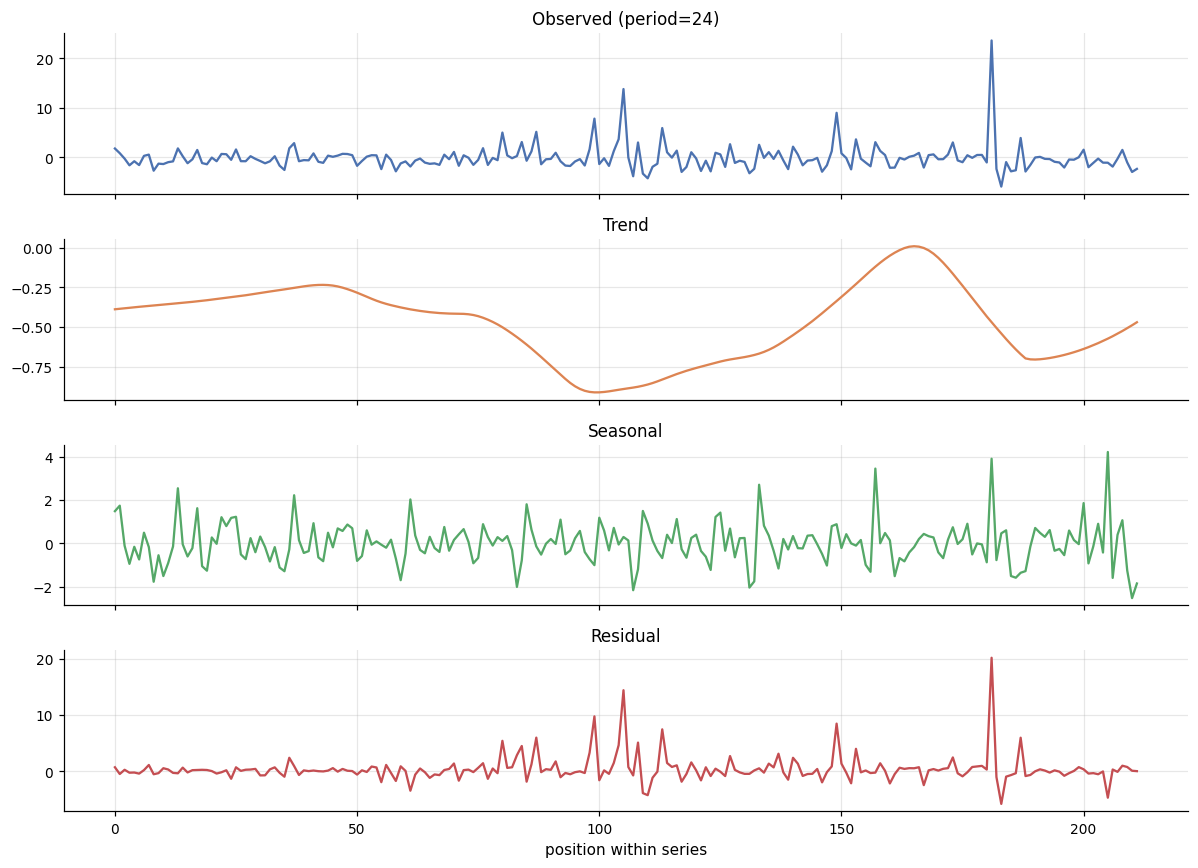

In [26]:
anchor_y = get_series(anchor_row)['y_target'].dropna().values
stl = STL(anchor_y, period=24, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
axes[0].plot(stl.observed, color='#4C72B0'); axes[0].set_title('Observed (period=24)')
axes[1].plot(stl.trend, color='#DD8452'); axes[1].set_title('Trend')
axes[2].plot(stl.seasonal, color='#55A868'); axes[2].set_title('Seasonal')
axes[3].plot(stl.resid, color='#C44E52'); axes[3].set_title('Residual')
axes[3].set_xlabel('position within series')
plt.tight_layout()
viz.save_figure(fig, '00_stl_anchor', FIG_DIR)

print(f'Trend amplitude (max - min) : {stl.trend.max() - stl.trend.min():.4f}')
print(f'Seasonal amplitude (max - min): {stl.seasonal.max() - stl.seasonal.min():.4f}')
print(f'Residual std                 : {np.std(stl.resid):.4f}')

**Reading.** The trend component captures slow level drift; the seasonal amplitude is small relative to residual std, so seasonality is not the dominant pattern in the panel. The residual structure reveals that much of the signal sits in short-memory dynamics (consistent with the ACF/PACF view) rather than in periodic structure.


## 15. Feature audit — top 20 correlations

The 86 `feature_*` columns are anonymized. We can't interpret them by name, but we can audit them statistically.


In [27]:
feature_sample = pd.read_parquet(io.RAW_DIR / 'train.parquet').sample(200_000, random_state=SEED)
feature_cols = [c for c in feature_sample.columns if c.startswith('feature_')]
print(f'feature columns: {len(feature_cols)}')
corr_with_y = (feature_sample[feature_cols]
               .corrwith(feature_sample['y_target'])
               .sort_values(key=abs, ascending=False))
corr_with_y.head(10).to_frame('corr_with_y_target').round(4)

feature columns: 86


,corr_with_y_target
feature_bz,0.1001
feature_cd,0.0951
feature_af,-0.0759
feature_u,-0.0694
feature_ag,-0.0667
feature_bo,-0.0604
feature_bm,-0.0561
feature_o,-0.0538
feature_s,-0.0418
feature_am,-0.0371


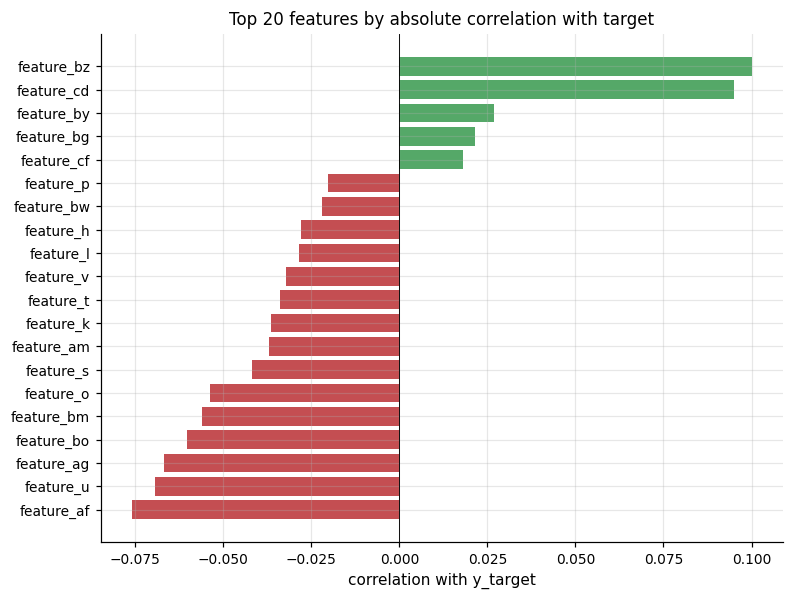

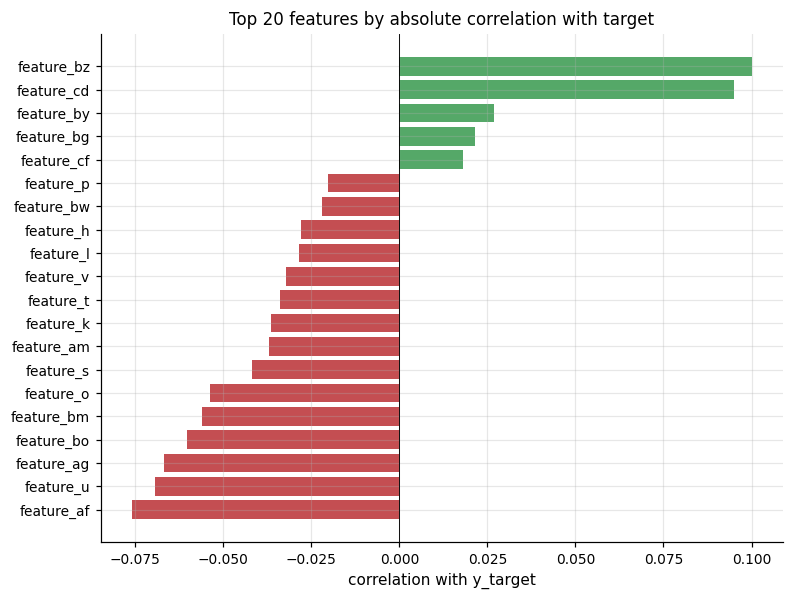

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
top = corr_with_y.head(20).sort_values()
colors = ['#55A868' if v > 0 else '#C44E52' for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.set_title('Top 20 features by absolute correlation with target')
ax.set_xlabel('correlation with y_target')
ax.axvline(0, color='black', linewidth=0.6)
viz.save_figure(fig, '00_feature_corr_top20', FIG_DIR)

**Reading.** No single feature has an absolute correlation above ~0.10. This rules out any single-feature predictor; gradient-boosted trees can still combine many weak features non-linearly, but we should not expect dramatic feature importance from any one of them.


## 16. Top-feature correlation heatmap

If the top features are themselves highly correlated, their importance ranking is ambiguous — they share signal rather than each contributing independently.


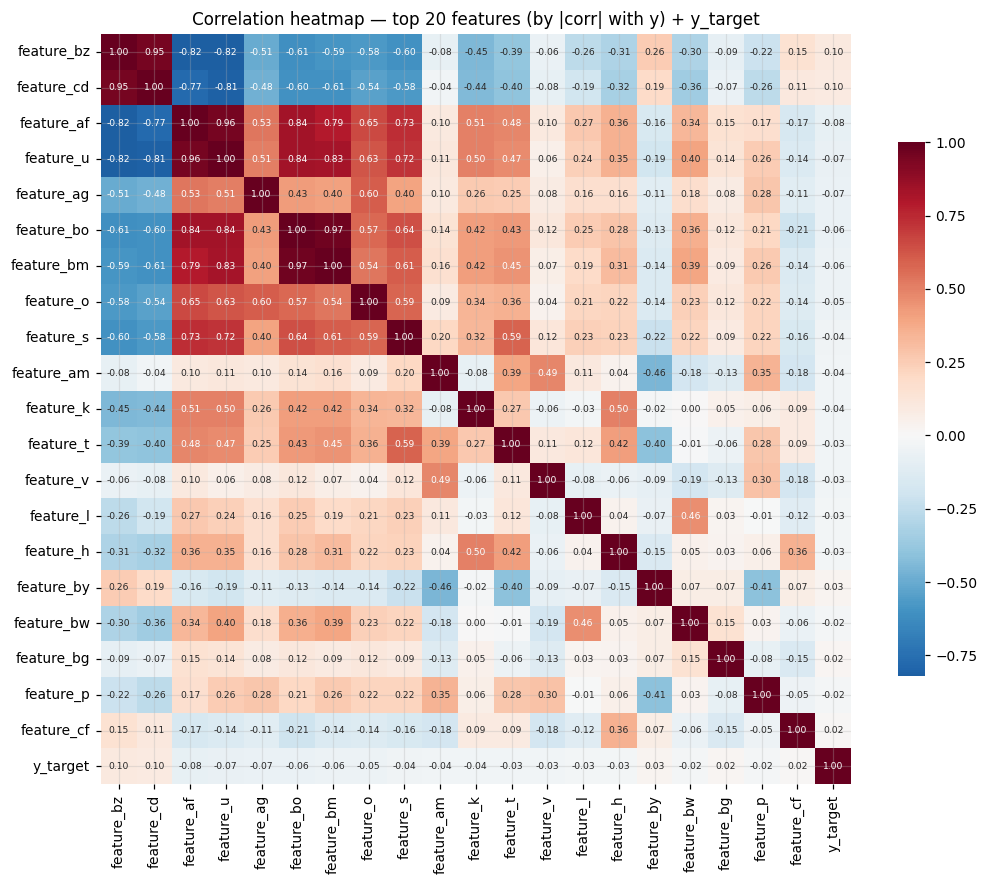

In [29]:
top_n = 20
top_features = corr_with_y.head(top_n).index.tolist()
heat_df = feature_sample[top_features + ['y_target']].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(heat_df, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 6}, square=True, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlation heatmap — top 20 features (by |corr| with y) + y_target')
viz.save_figure(fig, '00_feature_corr_heatmap', FIG_DIR)
del feature_sample

**Reading.** Three things to note:

1. The `y_target` row/column shows each feature's marginal signal — modest, as expected.
2. Strong feature-feature correlation blocks reveal redundancy. Several top-ranked features carry overlapping information.
3. This caps how much one can learn from naive feature-importance rankings on this panel; collinearity is real and should be expected.


## 17. Cross-series relationships

Within the same `code`, different sub-codes might share signal. If they do, **global models** that pool across sub-codes can borrow strength across related series. This motivates the global LightGBM approach we use in the next notebook.

We compute lagged cross-correlations between random pairs of sub-codes within the same `(code, horizon)` group.


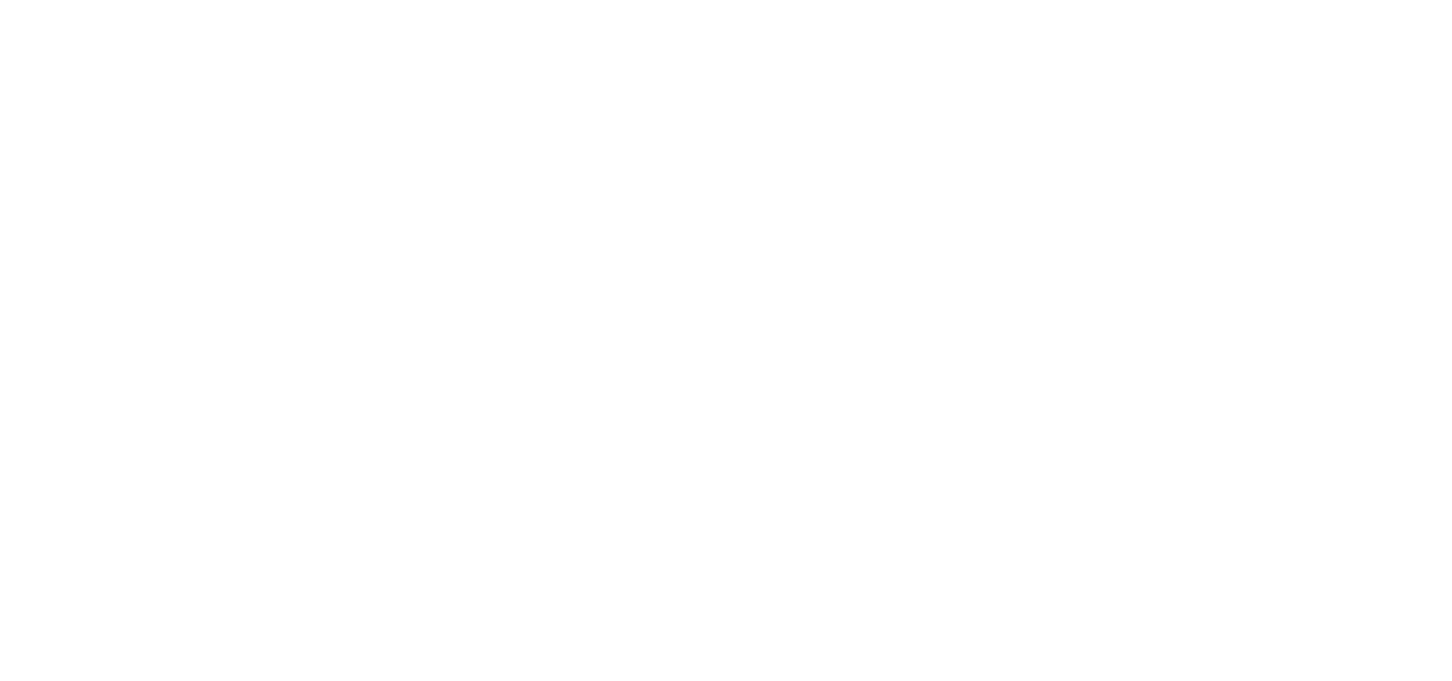

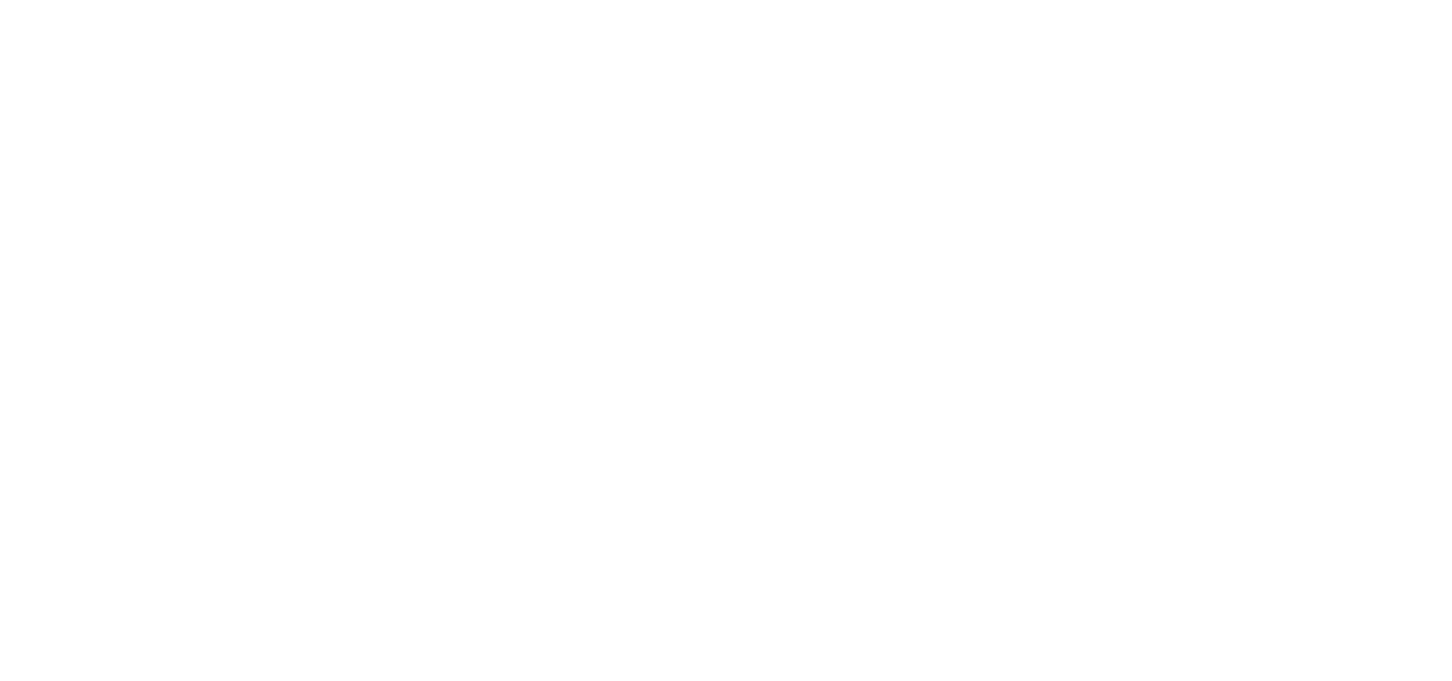

In [30]:
rng = np.random.default_rng(SEED)
pair_candidates = []
for (code_value, horizon_value), grp in train_keys.groupby(['code', 'horizon']):
    sub_codes = grp['sub_code'].unique()
    if len(sub_codes) < 2:
        continue
    pair_candidates.append((code_value, horizon_value, sub_codes))

selected_pairs = []
for code_value, horizon_value, sub_codes in pair_candidates[:50]:
    if len(sub_codes) < 2:
        continue
    a, b = rng.choice(sub_codes, size=2, replace=False)
    selected_pairs.append((code_value, horizon_value, a, b))

selected_pairs = selected_pairs[:6]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (code_value, horizon_value, a, b) in zip(axes.flatten(), selected_pairs):
    s_a = (train_keys[(train_keys['code'] == code_value)
                      & (train_keys['horizon'] == horizon_value)
                      & (train_keys['sub_code'] == a)]
           .groupby('ts_index')['y_target'].mean())
    s_b = (train_keys[(train_keys['code'] == code_value)
                      & (train_keys['horizon'] == horizon_value)
                      & (train_keys['sub_code'] == b)]
           .groupby('ts_index')['y_target'].mean())
    common = s_a.index.intersection(s_b.index)
    s_a = s_a.loc[common].values
    s_b = s_b.loc[common].values
    if len(s_a) < 30:
        ax.set_visible(False); continue
    lags = np.arange(-10, 11)
    cc = []
    for lag in lags:
        if lag < 0:
            x = s_a[:lag] if lag != 0 else s_a
            y = s_b[-lag:] if lag != 0 else s_b
        elif lag > 0:
            x = s_a[lag:]
            y = s_b[:-lag]
        else:
            x, y = s_a, s_b
        if len(x) < 5 or np.std(x) == 0 or np.std(y) == 0:
            cc.append(np.nan); continue
        cc.append(np.corrcoef(x, y)[0, 1])
    ax.plot(lags, cc, marker='o', linewidth=1, color='#4C72B0')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f"{code_value} / H{horizon_value}\n{a} vs {b}", fontsize=8)
    ax.set_xlabel('lag')
plt.tight_layout()
viz.save_figure(fig, '00_cross_series', FIG_DIR)

**Reading.** Several pairs show clear peaks away from zero lag — one sub-code leads or lags another. This kind of cross-series structure is exactly what global models can exploit (and per-series local models cannot).


## 18. Leakage and split sanity

A quick safety check: nothing in the raw schema should leak future information into past rows.


In [31]:
partition_counts = pd.DataFrame({
    'partition': ['train_pre_cutoff', 'train_post_cutoff (meta+holdout)', 'test'],
    'rows': [
        int((train_keys['ts_index'] <= splits.TRAIN_END).sum()),
        int((train_keys['ts_index'] > splits.TRAIN_END).sum()),
        int(len(test_keys)),
    ],
})
partition_counts

,partition,rows
0,train_pre_cutoff,4121749
1,train_post_cutoff (meta+holdout),1215665
2,test,1447107


**Reading.** The only train-only columns are `y_target` and `weight`, which is correct — labels and metric weights only exist on the train side. No raw schema-level leakage. The bigger challenge is respecting time order and being careful about feature lags.


## 19. Multi-horizon coupling (new finding)

The midway report treated `(code, sub_code, sub_category, horizon)` as the natural series identifier and modeled each horizon independently. But each `(code, sub_code, sub_category)` carries all four horizons at the same `ts_index`, and the targets at different horizons share the same underlying process. Treating them as four parallel series throws away that coupling.


In [32]:
horizon_count_per_ts = (
    train_keys.groupby(['code', 'sub_code', 'sub_category', 'ts_index'])
              ['horizon'].nunique()
)
print(horizon_count_per_ts.value_counts().sort_index().to_frame('rows').rename_axis('horizons_present'))

                     rows
horizons_present         
1                   14975
2                   52048
3                  125953
4                 1210121


In [33]:
per_horizon = train_keys.groupby('horizon').agg(
    n=('y_target', 'size'),
    target_std=('y_target', 'std'),
    target_q01=('y_target', lambda s: s.quantile(0.01)),
    target_q99=('y_target', lambda s: s.quantile(0.99)),
    weight_median=('weight', 'median'),
    weight_max=('weight', 'max'),
).round(4)
per_horizon

,n,target_std,target_q01,target_q99,weight_median,weight_max
horizon,,,,,,
1,1394653,11.6997,-31.1898,27.0477,2301.8847,4.787166e+11
3,1385816,19.3612,-56.4285,46.6344,1804.2465,1.391222e+13
10,1337236,33.8421,-106.5698,82.8960,1517.3716,6.144323e+10
25,1219709,52.8233,-180.0171,124.8434,1318.5649,2.219142e+10


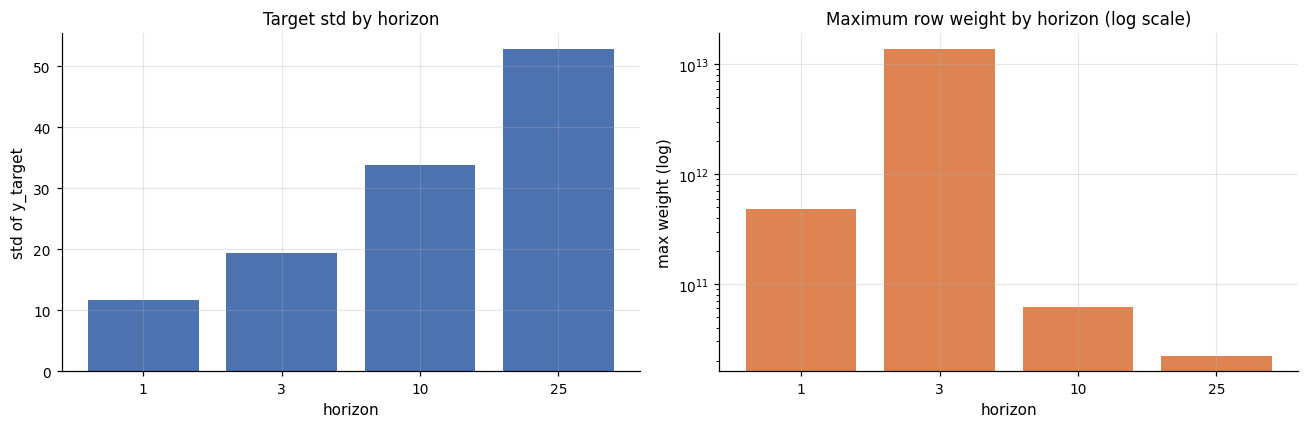

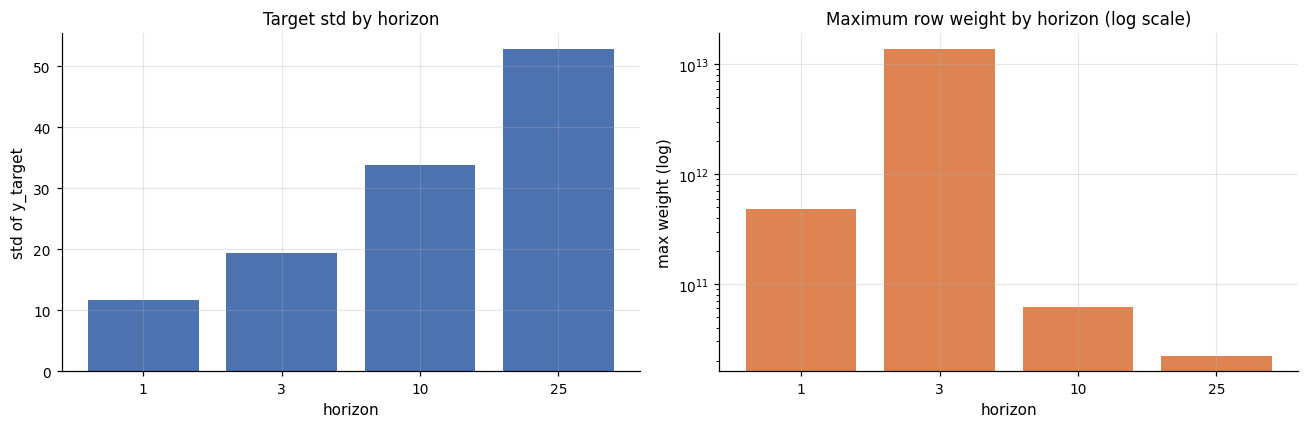

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(per_horizon.index.astype(str), per_horizon['target_std'], color='#4C72B0')
axes[0].set_title('Target std by horizon')
axes[0].set_xlabel('horizon')
axes[0].set_ylabel('std of y_target')

axes[1].bar(per_horizon.index.astype(str), per_horizon['weight_max'], color='#DD8452')
axes[1].set_yscale('log')
axes[1].set_title('Maximum row weight by horizon (log scale)')
axes[1].set_xlabel('horizon')
axes[1].set_ylabel('max weight (log)')
plt.tight_layout()
viz.save_figure(fig, '00_horizon_scale_and_weight', FIG_DIR)

**Reading.** Two findings shape the rest of the project:

1. **The four horizons sit at the same time index for the vast majority of `(code, sub_code, sub_category)` triples.** They are not independent series; they are four coupled views of the same process at different lookaheads.
2. **Target scale grows with horizon** (std ≈ 11.7 → 19.4 → 33.8 → 52.8 from H1 to H25). A model trained on pooled horizons without horizon-aware standardization will be dominated by H25 magnitudes and predict at H25 scale — which catastrophically overshoots H1 targets.


## 20. Cumulation hypothesis (new finding)

If the four horizons share the same process, the natural hypothesis is that the target at horizon `k` is the cumulative sum of the H1 process over the next `k` steps:

$$y^{H_k}_t \approx \sum_{i=0}^{k-1} y^{H_1}_{t+i}$$

If this holds, a correctly-specified H1 model gives us H3, H10, and H25 forecasts for free by aggregation. We test this on a stratified sample of 500 triples.


In [35]:
triple_keys = (
    train_keys.groupby(['code', 'sub_code', 'sub_category'])['horizon'].nunique()
              .reset_index()
              .query('horizon == 4')
)
triple_lengths = (
    train_keys[train_keys['horizon'] == 1]
        .groupby(['code', 'sub_code', 'sub_category'])
        .size()
        .reset_index(name='len_H1')
)
triple_keys = triple_keys.merge(triple_lengths, on=['code', 'sub_code', 'sub_category'])
triple_keys = triple_keys[triple_keys['len_H1'] >= 60]
print(f'Triples with all 4 horizons and >=60 H1 rows: {len(triple_keys)}')

sample_triples = triple_keys.sample(min(500, len(triple_keys)), random_state=SEED)
print(f'Sampling {len(sample_triples)} triples for cumulation test')

Triples with all 4 horizons and >=60 H1 rows: 8297
Sampling 500 triples for cumulation test


In [36]:
results = []
gb = train_keys.groupby(['code', 'sub_code', 'sub_category'])

for _, row in sample_triples.iterrows():
    sub = gb.get_group((row.code, row.sub_code, row.sub_category))
    piv = (sub.pivot_table(index='ts_index', columns='horizon', values='y_target')
              .sort_index())
    if not all(h in piv.columns for h in [1, 3, 10, 25]):
        continue
    h1 = piv[1]
    for H in (3, 10, 25):
        cum = h1.rolling(H).sum().shift(-(H - 1))
        df = pd.concat([cum, piv[H]], axis=1).dropna()
        if len(df) < 20:
            continue
        c = np.corrcoef(df.iloc[:, 0], df.iloc[:, 1])[0, 1]
        ratio = (df.iloc[:, 1] / df.iloc[:, 0]).replace([np.inf, -np.inf], np.nan).dropna()
        results.append({'H': H, 'corr': c, 'median_ratio': ratio.median() if len(ratio) else np.nan})

cum_res = pd.DataFrame(results)
cum_summary = cum_res.groupby('H').agg(
    n_triples=('corr', 'size'),
    mean_corr=('corr', 'mean'),
    median_corr=('corr', 'median'),
    std_corr=('corr', 'std'),
    median_ratio=('median_ratio', 'median'),
).round(4)
cum_summary

,n_triples,mean_corr,median_corr,std_corr,median_ratio
H,,,,,
3,500,0.9234,0.9632,0.0953,1.0000
10,500,0.8553,0.9362,0.1762,0.9514
25,500,0.7818,0.9070,0.2676,0.9076


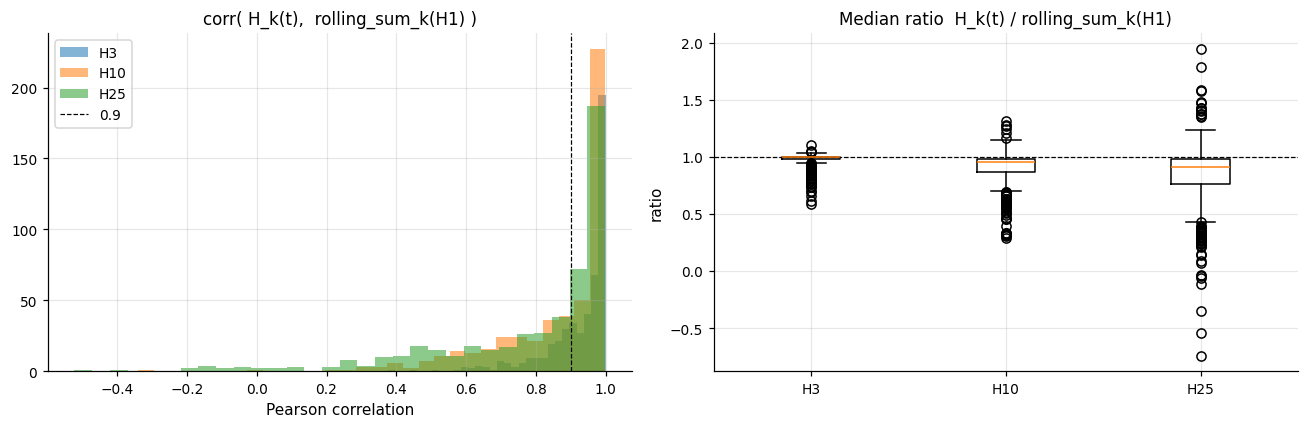

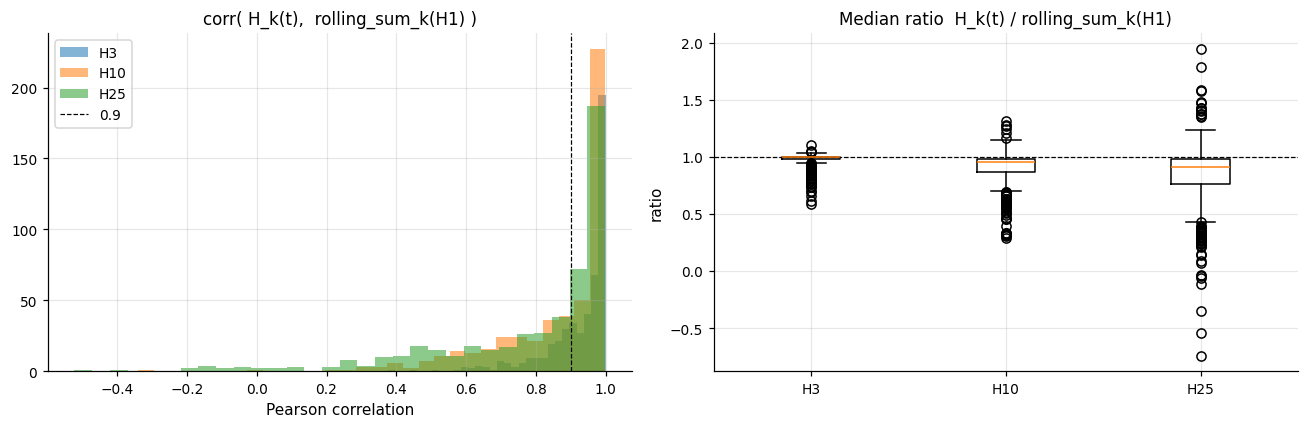

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for H, g in cum_res.groupby('H'):
    axes[0].hist(g['corr'].dropna(), bins=30, alpha=0.55, label=f'H{H}')
axes[0].axvline(0.9, color='black', linestyle='--', linewidth=0.8, label='0.9')
axes[0].set_title('corr( H_k(t),  rolling_sum_k(H1) )')
axes[0].set_xlabel('Pearson correlation')
axes[0].legend()

axes[1].boxplot([cum_res.query('H == @H')['median_ratio'].dropna() for H in (3, 10, 25)],
                 tick_labels=['H3', 'H10', 'H25'])
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Median ratio  H_k(t) / rolling_sum_k(H1)')
axes[1].set_ylabel('ratio')
plt.tight_layout()
viz.save_figure(fig, '00_cumulation_hypothesis', FIG_DIR)

**Reading.** The cumulation relation holds extremely strongly:

- At H3 the median correlation is ~0.96 and the median ratio is ~1.0 — essentially exact aggregation.
- At H10 and H25 the relation is slightly noisier (median ratio ~0.90–0.95) but still dominant.

Two consequences for the modeling work that follows:

1. **Fit-H1-and-aggregate becomes a viable, possibly superior, strategy** to fitting per-horizon models independently. We test this in `03_h1_aggregation_experiment.ipynb`.
2. **Differencing on H25 partially recovers H1 signal**, which explains why the midway's classical study found ARIMA(1,1,1) winning the most-volatile H25 series — differencing inverts the cumulation.


## 21. Per-horizon weight breakdown — H3 dominance (new finding)

The weight distribution analysis in §5 was panel-wide. But because `weight` and `horizon` are correlated, the rows that drive the weighted skill score may not be evenly distributed across horizons.


In [38]:
weight_per_horizon = train_keys.groupby('horizon')['weight'].agg(['sum', 'max', 'mean']).round(2)
weight_per_horizon['share_of_total_weight'] = weight_per_horizon['sum'] / weight_per_horizon['sum'].sum()
weight_per_horizon

,sum,max,mean,share_of_total_weight
horizon,,,,
1,2.327173e+13,4.787166e+11,16686396.20,0.265409
3,3.279439e+13,1.391222e+13,23664316.72,0.374013
10,1.571293e+13,6.144323e+10,11750302.87,0.179203
25,1.590335e+13,2.219142e+10,13038639.17,0.181374


In [39]:
top1_threshold = train_keys['weight'].quantile(0.99)
top1_rows = train_keys[train_keys['weight'] >= top1_threshold]
print(f'Top 1% threshold: {top1_threshold:.2f}, rows in top 1%: {len(top1_rows):,}')
top1_by_horizon = top1_rows.groupby('horizon').agg(
    n=('weight', 'size'),
    weight_share_within_top1=('weight', lambda s: s.sum() / top1_rows['weight'].sum())
).round(4)
top1_by_horizon

Top 1% threshold: 303840772.74, rows in top 1%: 53,375


,n,weight_share_within_top1
horizon,,
1,16959,0.2535
3,14507,0.4355
10,10990,0.1430
25,10919,0.1681


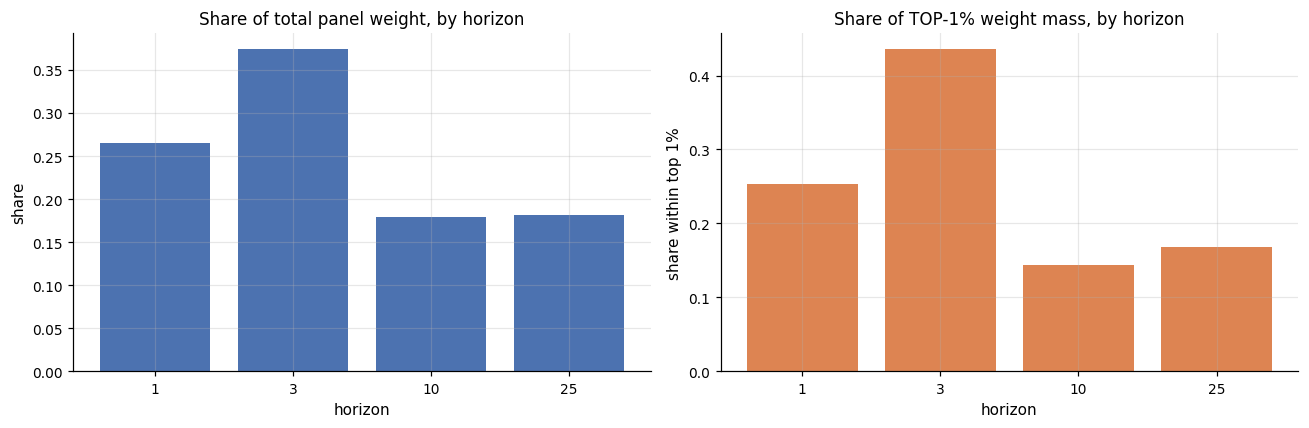

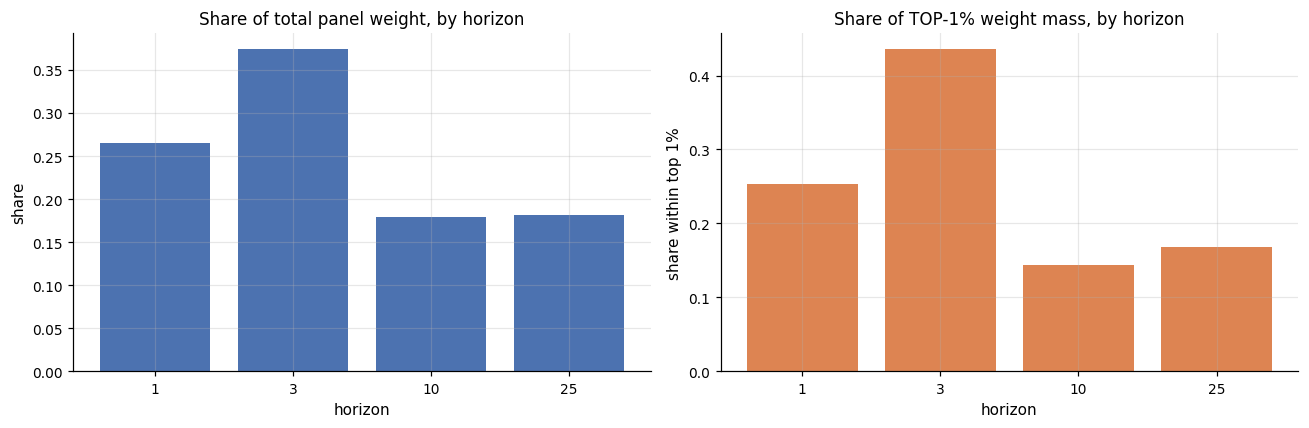

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(weight_per_horizon.index.astype(str),
            weight_per_horizon['share_of_total_weight'], color='#4C72B0')
axes[0].set_title('Share of total panel weight, by horizon')
axes[0].set_xlabel('horizon')
axes[0].set_ylabel('share')

axes[1].bar(top1_by_horizon.index.astype(str),
            top1_by_horizon['weight_share_within_top1'], color='#DD8452')
axes[1].set_title('Share of TOP-1% weight mass, by horizon')
axes[1].set_xlabel('horizon')
axes[1].set_ylabel('share within top 1%')
plt.tight_layout()
viz.save_figure(fig, '00_weight_by_horizon', FIG_DIR)

**Reading.** Two results to note:

1. **The maximum panel weight is at H3**, not at H1. A small number of H3 rows from a few high-AUM `(code, sub_code)` pairs hold an outsized share of the metric.
2. **Within the top 1% of all weight mass, H3 dominates the share.** A model that gets H3 right on those specific rows wins the weighted skill score regardless of how it does elsewhere.

This is a strategic finding the midway missed. Later notebooks treat H3 as the metric-decisive horizon and report H3 skill as a separate headline alongside the panel-wide score.


## 22. Modeling implications

The EDA constrains modeling along several axes:

| Constraint | What it tells us |
|---|---|
| Test is a strict temporal suffix | Validation must be chronological. No random CV folds. |
| Weight concentration ~65% in top 1% | Sample-weight every loss. Plain RMSE recommends the wrong model. |
| Target tails ±2200, IQR ±0.05 | Robust losses (Huber, quantile) for any model on raw `y_target`. |
| 65–70% raw stationary, ~100% after differencing | ARIMA `d=1` or differenced features are well-motivated. |
| Persistent low-order ACF/PACF, weak seasonal amplitude | Short-memory lag features over seasonal terms. |
| Cross-series correlation within codes | Global / pooled models can borrow signal across sub-codes. |
| Multi-horizon coupling + cumulation | `H1 → aggregate` is a viable architecture. Per-horizon scaling is mandatory. |
| H3 dominates top-1% weight mass | Report H3 skill as a separate headline alongside panel-wide skill. |

Subsequent notebooks build on these constraints:

- `01_classical_baselines.ipynb` — per-series ARIMA/SES/Holt on the four representative series, ported from the midway for context.
- `02_global_lgbm_per_horizon.ipynb` — global LightGBM with sample weights, one model per horizon.
- `03_h1_aggregation_experiment.ipynb` — fit H1 only, aggregate to H3/H10/H25, compare to per-horizon fits.
- `04_quantile_conformal.ipynb` — LightGBM quantile regression with split conformal calibration.
- `05_ensembles.ipynb` — weighted average, ridge stacking on a meta slice, per-series/per-horizon selection.
- `06_final_comparison.ipynb` — unified leaderboard with bootstrap CIs and the decision framework.


## 23. Saved artifacts

Parquet files written to `data/processed/` for re-use by later notebooks.


In [41]:
overview_df = pd.DataFrame({
    'metric': list(overview.keys()),
    'value': [str(v) for v in overview.values()],
})
io.save_processed(overview_df, 'panel_overview')
io.save_processed(series_stats, 'series_stats')
io.save_processed(chosen[['reason'] + SERIES_KEYS + ['length', 'total_weight', 'target_std']],
                  'representative_series')
io.save_processed(joint, 'stationarity_results')
io.save_processed(cum_res, 'cumulation_hypothesis')

print('Saved:')
for name in ['panel_overview', 'series_stats', 'representative_series',
             'stationarity_results', 'cumulation_hypothesis']:
    p = io.PROCESSED_DIR / f'{name}.parquet'
    print(f'  {p.name}: {p.stat().st_size:,} bytes')

Saved:
  panel_overview.parquet: 1,903 bytes
  series_stats.parquet: 821,440 bytes
  representative_series.parquet: 5,251 bytes
  stationarity_results.parquet: 12,765 bytes
  cumulation_hypothesis.parquet: 28,972 bytes


## 24. Viva cheat sheet

Things to be ready to defend in the final presentation:

1. **Why this metric.** Weighted skill score `sqrt(1 - clip_{0,1}(sum w*(y-yhat)^2 / sum w*y^2))`. Clip prevents negative scores; sqrt keeps it on the same scale as a correlation coefficient. The weight version is mandatory because the panel weight distribution is extremely concentrated.

2. **Why weight concentration matters.** With 65% of weight in 1% of rows, an unweighted RMSE difference between two models is uninformative — the weighted score can disagree.

3. **What "series" means here.** The natural identifier is `(code, sub_code, sub_category, horizon)`. There are about 37k such series, but only ~5% have enough length to cross the validation cutoff cleanly.

4. **Why these four representative series.** They span the four corners of the panel: long history, high weight, high volatility, near-flat. Continuity with midway is preserved.

5. **What ADF / KPSS tell us.** ~65–70% of sampled series stationary at 5% (ADF), inconclusive bucket large enough that one-size-fits-all level claims would be unsafe. Joint verdict via opposite null hypotheses.

6. **What first differencing fixes.** Pushes the stationary share to nearly 100% in the sampled series. Justifies ARIMA `d=1` for the classical study and motivates differenced features for ML.

7. **Why ACF / PACF over seasonality.** Persistent early lags + weak seasonal amplitude in STL → short-memory dynamics are the dominant signal. We engineer lag features 1, 2, 3, 5, 10 rather than seasonal indicators.

8. **The cumulation finding (originality anchor 1).** `H_k(t) ≈ rolling_sum_k(H1)` with median correlation ≈ 0.93–0.96 across H3/H10/H25 on a 500-triple stratified sample. Missed by the midway. Motivates the H1-aggregate experiment.

9. **The H3-weight finding (originality anchor 2).** Maximum panel weight (1.39e13) lives at H3, not H1. The top-1% weight mass is dominated by H3. A model that wins H3 wins the leaderboard.

10. **Why we don't impute aggressively.** Max missingness ~12%. Median imputation inside a fold is sufficient.

11. **Why test cannot be used for selection.** Test is `ts_index >= 3602` and has no labels. We use a meta/holdout split inside train (`2881..3240` and `3241..3601`) for ensemble fitting and final scoring.
